# AFM Simulation and Regression Model


**This notebook provides a complete example on how to create a simulated AFM dataset and how to train a regression model for post-processing.**

The first section simulates a dataset while the second section builds and trains a model. Finally, the user can test the model on their experimental data. The notebook provides two final **Output**; **1:** A simulated AFM dataset, **2:** A trained model ready to process experimental data.

## 1. Optional installations

Uncomment the lines if using Colab/Kaggle.

In [1]:
#!pip3 install deeplay plotly ipywidgets ipympl

# from google.colab import output
# output.enable_custom_widget_manager()

## 2. Imports and configuration

Here we import necessary libraries and scripts.

In [2]:
import os

from __future__ import annotations

from dataclasses import dataclass
from typing import List

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

torch.set_num_threads(1)

We configure our simulator and model. The user must configure the experimental parameters, sample parameters and if desired the model parameters to adapt to their experimental setup.

1. **SimulationConfig**:
    1. The user must select the scan resolution that consists of pixel number $(n_x, n_y)$ and pixel size.
    2. Force-distance curve (FDC) parameters must be defined: $z~length$, $z~speed$, sampling frequency $f_s$ and $set-point~force$.
    3. Depending on the cantilever choice the tip shape and the desired thermal noise type must be selected.
    4. Curve mode must be selected between 'approach' and 'approach-retract'. This will depend on the used contact mechanics model.
3. **DatasetConfig**:
    1. Quantity of samples for training, validating and testing must be indicated.
    2. Topography types we want to use and the height range we are expecting.
    3. Range of stiffness for the substrate and the sample must be indicated. This is only an estimation and doesn't need to be precise.
5. **ModelConfig**:
    1. This contains the parameters of the model. The user does not need to adjust these values but it can b emodified if desired.

In [3]:
SEED = 69
np.random.seed(SEED)
torch.manual_seed(SEED)

Array = np.ndarray


@dataclass
class SimulationConfig:
    nx = 16
    ny = 16
    pixel_size_m = 2e-6
    z_length_m = 3e-6
    z_speed_um_s = 9.0
    sampling_frequency_hz = 900
    setpoint_force_n_range = [1.0e-9, 1e-9]
    tip_shape = "Sphere"
    include_thermal_noise = True
    noise_type = "experimental"
    experimental_noise_path = \
      "../data/thermal-noise-data_vDeflection_2025.11.28-16.42.57.tnd"
    curve_mode = "approach"  # options: "approach", "approach_retract"

@dataclass
class DatasetConfig:
    n_samples = 1500
    topography_types = ("gaussian_features", "hemisphere")
    substrate_stiffness_range_pa = (0.1e3, 5e3)
    feature_stiffness_range_pa = (0.1e3, 5e3)
    height_range_m = (0.2e-6, 2e-6)
    contact_point_range_m = (0.01e-6, 2.9e-6)

@dataclass
class ModelConfig:
    batch_size = 128
    learning_rate = 2e-3
    max_epochs = 1000
    predict_contact_point = True
    cp_loss_weight = 0.5
    num_workers = 0
    accelerator = "auto"
    devices = 1
    default_sample_to_display = 0


simulation_config = SimulationConfig()
dataset_config = DatasetConfig()
model_config = ModelConfig()

print(simulation_config)
print(dataset_config)
print(model_config)


SimulationConfig()
DatasetConfig()
ModelConfig()


## 3. Cantilever model with PSD


The `AFMCantilever` class represents the physical cantilever. Required inputs are: tip geometry, tip size, spring constant, resonance frequency, quality factor, and temperature — all available on the cantilever box or thermal calibration file.

The class handles two responsibilities: computing the contact area for a given indentation, and generating thermal noise. Three noise options are provided:

1. **Equipartition theorem**: The mean square displacement of the cantilever under thermal fluctuations is equal to $ k_B T / k $ under the equipartitoin theorem. In order to use this option the spring constant of the cantilever and the temperature we operate in must be known. Select 'rms' for the noise type.
   
2. **Theoretical PSD**: The cantilever behaves as a damped harmonic oscillator for which we can compute the power spectral density (PSD) that we denote as $S(f_x, f_y)$. Depending on our sampling frequency we compute a time domain noise from the theoretical PSD. Alongside the spring constant of the cantilever and the temperature, the user must also input the resonant frequency and the quality factor of the cantilever. Select 'Theoretical' for the noise type.
   
3. **Experimental PSD**: In the beginning of an AFM experiment the software measures the PSD of the cantilever in order to do thermal calibration. In this option the time domain noise is generated from the experimental PSD. Select 'Experimental' for the noise type and provide the path that leads to the '.tnd' calibration file.

In [4]:
class AFMCantilever:
    """AFM cantilever model with thermal-noise PSD support.

    This class represents the cantilever and stores parameters relevant to its
    thermal noise characteristics, allowing for both theoretical and
    experimental PSDs to be used in simulations.

    Parameters
    ----------
    k : float
        Spring constant in N/m.
    f0 : float
        Resonance frequency in Hz.
    Q : float
        Quality factor.
    T : float
        Temperature in kelvin.

    """

    def __init__(
        self,
        k: float =0.1,
        f0: float =7e3,
        Q: float =10.0,
        T: float =300.0
    ) -> None:
        """Initializes the AFMCantilever.

        Initializes the AFMCantilever with given parameters and computes
        derived properties.

        Parameters
        ----------
        k : float, optional
            Spring constant in N/m (default is 0.1).
        f0 : float, optional
            Resonance frequency in Hz (default is 7e3).
        Q : float, optional
            Quality factor (default is 10.0).
        T : float, optional
            Temperature in kelvin (default is 300.0).

        """

        self.k = k
        self.f0 = f0
        self.Q = Q
        self.T = T
        self.kB = 1.380649e-23
        self.m_eff = k / (2.0 * np.pi * f0) ** 2
        self.gamma = 2.0 * np.pi * f0 * self.m_eff / Q
        self._experimental_psd_cache = {}
        self._grid_psd_cache = {}

    def thermal_noise_rms(
            self
        ) -> float:
        """Return the RMS thermal deflection in meters.

        Returns
        -------
        float
            RMS thermal deflection in meters.

        """

        return np.sqrt(self.kB * self.T / self.k)

    def thermal_noise_psd_theoretical(
        self,
        frequency_hz: np.ndarray
    ) -> np.ndarray:
        """Return the one-sided theoretical displacement PSD.

        Parameters
        ----------
        frequency_hz : np.ndarray
                Frequencies in Hz at which to evaluate the PSD.

        Returns
        -------
        np.ndarray
            PSD in m^2/Hz.

        """

        omega  = 2.0 * np.pi * frequency_hz
        omega0 = 2.0 * np.pi * self.f0
        denom  = (omega0**2 - omega**2)**2 + (omega * omega0 / self.Q)**2
        return (4.0 * self.kB * self.T * self.gamma) / (self.k**2 * denom)

    def thermal_noise_psd_experimental(
        self,
        path: str
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Load and cache an experimental displacement PSD.

        Loads the experimental PSD from the provided path. Converts the
        displacement from volts to meters using the metadata in the file.

        Parameters
        ----------
        path : str
            Path to the experimental PSD file.

        Returns
        -------
        tuple of np.ndarray
            (frequency_hz, spectral_density_x, spectral_density_x_fit)

        """

        cache_key = str(path)
        if cache_key not in self._experimental_psd_cache:
            data = np.loadtxt(path, skiprows=24)
            frequency_hz       = data[:, 0]
            spectral_density_v = data[:, 1]
            spectral_density_v_fit = data[:, 3]
            with open(path, "r") as f:
                lines = f.readlines()
            for line in lines:
                if "sensitivity" in line:
                    volts_to_displacement_nm = \
                      float(line.split(":")[1].split()[0])
                if "parameter.f" in line:
                    self.f0 = float(line.split(":")[1].split()[0]) * 1e3
                if "parameter.Q" in line:
                    self.Q = float(line.split(":")[1].split()[0])
            scale = volts_to_displacement_nm * 1e-9
            self._experimental_psd_cache[cache_key] = (
                frequency_hz,
                spectral_density_v     * scale**2,
                spectral_density_v_fit * scale**2,
            )
        return self._experimental_psd_cache[cache_key]

    def get_noise_psd(
        self,
        n_points: int,
        sampling_frequency_hz: float,
        noise_type: str = simulation_config.noise_type,
        experimental_path: str = simulation_config.experimental_noise_path
    ) -> tuple[np.ndarray, np.ndarray]:
        """Returns the simulation-grid PSD.

        Returns the theoretical PSD calculated with the harmonic oscillator
        model. When it's possible the cached results are reused.

        Parameters
        ----------
        n_points : int
            Number of points in the simulation grid.
        sampling_frequency_hz : float
            Sampling frequency in Hz.
        noise_type : str
            Type of noise ("theoretical", "experimental" or "rms").
        experimental_path : str or None
            Path to the experimental PSD file.

        Returns
        -------
        tuple of np.ndarray
            (frequency_hz, spectral_density_x)

        """

        cache_key = (noise_type.lower(), int(n_points), \
                     float(sampling_frequency_hz),None if experimental_path
                     is None else str(experimental_path))
        if cache_key in self._grid_psd_cache:
            return self._grid_psd_cache[cache_key]

        frequency_hz = np.fft.rfftfreq(n_points, d=1.0 / sampling_frequency_hz)
        if noise_type.lower() == "theoretical":
            spectral_density_x = \
              self.thermal_noise_psd_theoretical(frequency_hz)
        elif noise_type.lower() == "experimental":
            if experimental_path is None:
                raise ValueError("`experimental_path` must be provided for \
                experimental PSD.")
            frequency_hz, spectral_density_x, _ = (
                self.thermal_noise_psd_experimental(experimental_path)
            )
        else:
            raise ValueError(f"Unknown noise type: {noise_type}")

        self._grid_psd_cache[cache_key] = (frequency_hz, spectral_density_x)
        return self._grid_psd_cache[cache_key]

    def sample_thermal_noise(
        self,
        n_points: int,
        sampling_frequency_hz: float,
        noise_type: str = simulation_config.noise_type,
        experimental_path: str = simulation_config.experimental_noise_path,
        rng=None
    ) -> np.ndarray:
        """Draws one thermal-noise trace from the PSD.

        Draws one trace of thermal noise from the PSD using random phase and
        converts it to time domain noise using np.fft.irfft

        Parameters
        ----------
        n_points : int
            Number of points in the simulation grid.
        sampling_frequency_hz : float
            Sampling frequency in Hz.
        noise_type : str
            Type of noise ("theoretical", "experimental" or "rms").
        experimental_path : str or None
            Path to the experimental PSD file.
        rng : numpy.random.Generator or None
            Random number generator instance. If None, a new instance is
            created.

        Returns
        -------
        np.ndarray
            Noise trace in meters, shape (n_points,).

        """

        rng = np.random.default_rng() if rng is None else rng
        frequency_hz, spectral_density_x = self.get_noise_psd(
            n_points, sampling_frequency_hz, noise_type, experimental_path
        )
        df        = sampling_frequency_hz / n_points

        amplitude = n_points * \
                            np.sqrt(np.maximum(spectral_density_x * df/2, 0.0))
        coefficients = np.zeros(amplitude.shape[0], dtype=np.complex128)

        if amplitude.shape[0] > 2:
            phase = rng.uniform(0.0, 2.0 * np.pi, size=amplitude.shape[0] - 2)
            coefficients[1:-1] = amplitude[1:-1] * np.exp(1j * phase)
        coefficients[0] = 0.0
        if n_points % 2 == 0 and amplitude.shape[0] > 1:
            coefficients[-1] = amplitude[-1] * np.sign(rng.standard_normal())

        noise_m = np.fft.irfft(coefficients, n=n_points).real
        rms      = self.thermal_noise_rms()
        std      = np.std(noise_m)
        # Guard against zero std.
        if std > 0:
            noise_m = noise_m / std * rms
        else:
            noise_m = rng.normal(scale=rms, size=n_points)
        return noise_m


**Thermal noise from file**

Uncomment and run this cell if you wish to load an experimental thermal calibration file. When running locally, store the file in the folder with the script and make sure that the path is accessible.

In [5]:
# from google.colab import files
# import os

# print("Upload your experimental PSD text file (e.g., .txt or .csv):")
# uploaded = files.upload()
# for filename in uploaded.keys():
#      print(f'Uploaded "{filename}" ({len(uploaded[filename])} bytes)')
#      simulation_config.experimental_noise_path = filename
#      simulation_config.noise_type = "Experimental"


## 4. Contact mechanics


The `HertzContact` class transforms indentation depth into a force response. The Hertz model is provided as an example suited to biological applications. You can replace it with any contact model appropriate for your experiment.

In [6]:
class HertzContact:
    """Hertz contact model for spherical and pyramidal tips.

    Represents the relationship between indentation and force. Stores
    information related to contact geometry and contact mechanics.

    Parameters
    ----------
    R: float
        Tip radius in meters.
    nu: float
        Poisson ratio of the sample.
    alpha: float
        Pyramid face angle in degrees.

    """

    def __init__(
        self,
        R: float = 10e-9,
        nu: float = 0.5,
        alpha: float = 18.0
    ) -> None:
        """Initializes the HertzContact model.

        Initializes the HertzContact model with given parameters.

        Parameters
        ----------
        R: float
            Tip radius in meters.
        nu: float
            Poisson ratio of the sample.
        alpha: float
            Pyramid face angle in degrees.

        """

        self.R = R
        self.nu = nu
        self.alpha = alpha

    @property
    def alpha_rad(
        self
    ) -> float:
        """Return the pyramid face angle in radians.

        Returns
        -------
        float
            Pyramid face angle in radians.

        """

        return np.deg2rad(self.alpha)

    def hertz_sphere(
        self,
        indentation_m: float,
        stiffness_pa: float
    ) -> float:
        """Return the Hertz force for a spherical tip.

        Returns the force response of a purely elastic semi finite substrate
        with the given stiffness in response to given indentation depth for a
        spherical indentor.

        Parameters
        ----------
        indentation_m : float
            Indentation depth in meters.
        stiffness_pa : float
            Young's modulus in pascal.

        Returns
        -------
        float
            Contact force in newtons.

        """

        return (
            (4.0 / 3.0)
            * stiffness_pa
            * np.sqrt(self.R)
            * indentation_m**1.5
            / (1.0 - self.nu**2)
        )

    def hertz_cone(
        self,
        indentation_m: float,
        stiffness_pa: float
    ) -> float:
        """Return the Hertz-like force for a conical approximation.

        Returns the force response of a purely elastic semi finite substrate
        with the given stiffness in response to given indentation depth for a
        conical indentor.

        Parameters
        ----------
        indentation_m : float
            Indentation depth in meters.
        stiffness_pa : float
            Young's modulus in pascal.

        Returns
        -------
        float
            Contact force in newtons.

        """

        return (
            stiffness_pa
            * np.tan(self.alpha_rad)
            * indentation_m**2
            / (np.sqrt(2.0) * (1.0 - self.nu**2))
        )

    def force(
        self,
        cantilever_shape: str,
        indentation_m: float,
        stiffness_pa: float
    ) -> float:
        """Return the contact force for the given indentation.

        Parameters
        ----------
        cantilever_shape: str
            Tip geometry, either ``'Sphere'`` or ``'Pyramid'``.
        indentation_m: float
            Indentation depth in meters.
        stiffness_pa: float
            Young's modulus in pascal.

        Returns
        -------
        float
            Contact force in newtons.

        """

        indentation_safe_m = \
          np.maximum(np.asarray(indentation_m, dtype=np.float64), 0.0)
        if cantilever_shape == "Sphere":
            return self.hertz_sphere(indentation_safe_m, stiffness_pa)
        if cantilever_shape == "Pyramid":
            return self.hertz_cone(indentation_safe_m, stiffness_pa)
        raise ValueError(f"Unsupported cantilever shape: {cantilever_shape}")


## 5. Synthetic sample-map generator


The `SampleGenerator` class builds a synthetic sample. You provide topography type and mechanical property ranges; the class returns a 2D topography map, a stiffness map, and a **contact point map**.

### Contact point convention

The contact point is defined as the **absolute z-position along the displacement axis** at which the tip first touches the sample surface. A large contact-point value means the tip is still far from the surface when first contact occurs (i.e., the approach has barely started). A small value means the tip nearly traverses the full scan range before touching.




In [7]:
class SampleGenerator:
    """Generate topography, stiffness, and contact-point maps.

    Generates synthetic sample maps with specified topography types, stiffness
    ranges, and contact point ranges.

    """

    def __init__(
        self,
        substrate_stiffness_range_pa: tuple = (5e3, 10e3),
        feature_stiffness_range_pa: tuple = (2e3, 5e3),
        height_range_m: tuple = (1e-6, 4e-6),
        contact_point_range_m: tuple = (5.0e-6, 9.75e-6),
    ) -> None:
        """Initializes the SampleGenerator with specified parameters.

        Initializes the SampleGenerator with given stiffness ranges, height
        ranges, and contact point ranges.

        Parameters
        ----------
        substrate_stiffness_range_pa: tuple
            Range of substrate stiffness in pascal (min, max).
        feature_stiffness_range_pa: tuple
            Range of feature stiffness in pascal (min, max).
        height_range_m: tuple
            Range of feature heights in meters (min, max).
        contact_point_range_m: tuple
            Range of contact points in meters (min, max).

        """

        self.substrate_stiffness_range_pa = substrate_stiffness_range_pa
        self.feature_stiffness_range_pa = feature_stiffness_range_pa
        self.height_range_m = height_range_m
        self.contact_point_range_m = contact_point_range_m

    def create_topography(
        self,
        size: tuple = (128, 128),
        pixel_size_m: float = 1e-6,
        topography_type: str = "gaussian_features",
        rng=None
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Create one synthetic sample map.

        Parameters
        ----------
        size: tuple
            Map dimensions as ``(ny, nx)`` in pixels.
        pixel_size_m: float
            Physical size of one pixel in meters.
        topography_type: str
            ``'gaussian_features'`` or ``'hemisphere'``.
        rng: Optional[numpy.random.Generator]
            Optional numpy random generator.

        Returns
        -------
        tuple[np.ndarray, np.ndarray, np.ndarray]
            Tuple of ``(topography_m, stiffness_map_pa, contact_point_map_m)``.

        """

        rng = np.random.default_rng() if rng is None else rng
        ny, nx = size
        topography_m = np.ones((ny, nx), dtype=np.float64) * 1e-8
        stiffness_map_pa = rng.uniform(
            self.substrate_stiffness_range_pa[0],
            self.substrate_stiffness_range_pa[1],
            size=(ny, nx),
        )

        if topography_type == "gaussian_features":
            n_features = int(rng.integers(4, 10))
            y, x = np.ogrid[0:ny, 0:nx]
            for _ in range(n_features):
                cx = int(rng.integers(0, nx))
                cy = int(rng.integers(0, ny))
                amplitude = float(rng.uniform(*self.height_range_m))
                sigma_px = float(rng.uniform(3.0, 10.0))
                gaussian = amplitude * np.exp(
                    -((x - cx) ** 2 + (y - cy) ** 2) / (2.0 * sigma_px**2)
                )
                topography_m += gaussian
        elif topography_type == "hemisphere":
            radius_px = min(nx, ny) // 4
            cx, cy = nx // 2, ny // 2
            y, x = np.ogrid[:ny, :nx]
            r2 = (x - cx) ** 2 + (y - cy) ** 2
            mask = r2 <= radius_px**2
            topography_m[mask] = self.height_range_m[1] * np.sqrt(
                1.0 - r2[mask] / radius_px**2
            )
        else:
            raise ValueError(f"Unsupported topography type: {topography_type}")

        feature_mask = topography_m > np.percentile(topography_m, 70.0)
        stiffness_map_pa[feature_mask] = rng.uniform(
            self.feature_stiffness_range_pa[0],
            self.feature_stiffness_range_pa[1],
            size=int(feature_mask.sum()),
        )

        if float(topography_m.max()) > float(topography_m.min()):
            normalized_topography = (topography_m - topography_m.min()) / (
                topography_m.max() - topography_m.min()
            )
        else:
            normalized_topography = np.zeros_like(topography_m)

        cp_min, cp_max = self.contact_point_range_m
        contact_point_map_m = np.interp(
            normalized_topography,
            (0.0, 1.0),
            (cp_max, cp_min),
        )
        contact_point_map_m = np.clip(contact_point_map_m, cp_min, cp_max)

        return topography_m, stiffness_map_pa, contact_point_map_m


## 6. AFM simulator


The `AFMSimulator` combines all previous classes into a vectorised map simulator. It returns 2D maps of force-distance curves, each with additive thermal noise.

In [8]:
class AFMSimulator:
    """AFM curve simulator with setpoint-triggered retract.

    Combines the cantilever dynamics with the contact model for every pixel in
    a given sample. The approach is stopped at the exact z-position where the
    Hertz force equals ``setpoint_force_n`` or exceeds it.

    Parameters
    ----------
    cantilever : AFMCantilever
        Cantilever model for the AFM simulation.
    contact_model : HertzContact
        Contact model for the AFM simulation.
    sample_generator : SampleGenerator
        Sample generator for the AFM simulation.
    config : SimulationConfig
        Configuration for the AFM simulation.

    """

    def __init__(
        self,
        cantilever,
        contact_model,
        sample_generator,
        config
    ) -> None:
        """Initializes the AFMSimulator with the given components and configuration.

        Initializes the AFMSimulator with the provided cantilever, contact model, sample generator, and simulation configuration.
        Precomputes the approach axis and the number of points for the approach phase based on the simulation configuration.

        Parameters
        ----------
        cantilever : AFMCantilever
            Cantilever model for the AFM simulation.
        contact_model : HertzContact
            Contact model for the AFM simulation.
        sample_generator : SampleGenerator
            Sample generator for the AFM simulation.
        config : SimulationConfig
            Configuration for the AFM simulation.

        """

        self.cantilever      = cantilever
        self.contact_model   = contact_model
        self.sample_generator = sample_generator
        self.config          = config
        self.n_points_approach = self._compute_n_points_approach()
        self.approach_axis_m   = self._build_approach_axis()

    def _compute_n_points_approach(
        self
    ) -> int:
        """ Compute the number of points for the approach phase

        Computes the number of points for the approach phasebased on the z-length,
        z-speed, and sampling frequency.

        Returns
        -------
        int
            Number of points for the approach phase, at least 32.

        """

        total_time_s = self.config.z_length_m / \
          (self.config.z_speed_um_s * 1e-6)
        return max(32, int(np.ceil(total_time_s * \
                                    self.config.sampling_frequency_hz)))

    def _build_approach_axis(
        self
    ) -> np.ndarray:
        """Build the approach displacement axis.

        Builds the approach displacement axis as a linearly spaced array from 0 to z_length_m with n_points_approach points.

        Returns
        -------
        np.ndarray
            Approach displacement axis in meters, shape (n_points_approach,).

        """

        return np.linspace(0.0, self.config.z_length_m, \
                           self.n_points_approach, \
                            endpoint=True, dtype=np.float64)

    def _retract_axis(
        self,
        z_start_m: float
    ) -> np.ndarray:
        """Return the retract displacement axis

        Returns the retract displacement axis starting from ``z_start_m``.

        Parameters
        ----------
        z_start_m : float
            Starting z-position for the retract phase in meters.

        Returns
        -------
        np.ndarray
            Retract displacement axis in meters.

        """

        z_stop_m = max(0.0, z_start_m - self.config.z_length_m)
        if z_stop_m >= z_start_m:
            return np.zeros(0, dtype=np.float64)
        n = max(1, int(np.ceil(
            (z_start_m - z_stop_m) / (self.config.z_speed_um_s * 1e-6) \
            * self.config.sampling_frequency_hz
        )))
        return np.linspace(z_start_m, z_stop_m, n + 1, \
                           endpoint=True)[1:].astype(np.float64)

    def simulate_force_map(
        self,
        stiffness_map_pa: np.ndarray,
        contact_point_map_m: np.ndarray,
        include_thermal_noise: bool = True,
        noise_type: str = simulation_config.noise_type,
        experimental_path: str = simulation_config.experimental_noise_path,
        rng: np.random.Generator = None
    ) -> dict:
        """Simulate a map of force curves.

        Simulates a map of force curves with exact setpoint termination.

        Parameters
        ----------
        stiffness_map_pa : np.ndarray, shape (ny, nx)
            Stiffness map in pascals.
        contact_point_map_m : np.ndarray, shape (ny, nx)
            Contact point map in meters.
        include_thermal_noise : bool, optional
            Whether to include thermal noise in the simulation.
        noise_type : str, optional
            Type of noise to include. Options: "theoretical", "experimental".
        experimental_path : str or None, optional
            Path to experimental PSD file, if ``noise_type`` is "experimental".
        rng : numpy.random.Generator or None, optional
                Optional random number generator for reproducibility.

        Returns
        -------
        dict
            Keys: ``displacement_curves_m``,``force_curves_n``, 
            ``measured_force_curves_n``,``curve_lengths``, 
            ``retract_start_indices``,``contact_indices``.

        """

        rng = np.random.default_rng() if rng is None else rng
        ny, nx = stiffness_map_pa.shape

        # Vectorised approach force over the full grid.
        approach_indent = np.maximum(
            self.approach_axis_m[None, None, :] - \
                              contact_point_map_m[..., None], 0.0
        )
        approach_force = self.contact_model.force(
            cantilever_shape=self.config.tip_shape,
            indentation_m=approach_indent,
            stiffness_pa=stiffness_map_pa[..., None],
        )  # (ny, nx, n_points_approach)

        # First grid index where force >= setpoint.
        setpoint_force_n = rng.uniform(min(self.config.setpoint_force_n_range), max(self.config.setpoint_force_n_range))
        exceeded       = approach_force >= setpoint_force_n
        first_exceed   = np.argmax(exceeded, axis=-1)
        never_reached  = ~np.any(exceeded, axis=-1)
        first_exceed[never_reached] = self.n_points_approach - 1

        # Contact index (first sample at or past the contact point).
        contact_indices = np.clip(
            np.searchsorted(self.approach_axis_m, contact_point_map_m.ravel(),
                            side="left"),
            0, self.n_points_approach - 1,
        ).reshape(contact_point_map_m.shape)

        # Per-pixel variable-length curves.
        displacement_curves_m   = np.empty((ny, nx), dtype=object)
        force_curves_n          = np.empty((ny, nx), dtype=object)
        measured_force_curves_n = np.empty((ny, nx), dtype=object)
        curve_lengths           = np.zeros((ny, nx), dtype=np.int32)
        retract_start_indices   = np.zeros((ny, nx), dtype=np.int32)

        for r in range(ny):
            for c in range(nx):
                cp    = float(contact_point_map_m[r, c])
                E     = float(stiffness_map_pa[r, c])
                ei    = int(first_exceed[r, c])
                never = bool(never_reached[r, c])

                # ── approach ─────────────────────────────────────────────────
                if never or ei == 0:
                    app_z = self.approach_axis_m.copy()
                    app_f = approach_force[r, c].copy()
                else:
                    app_z = self.approach_axis_m[:ei]
                    app_f = approach_force[r, c, :ei]


                # ── retract ──────────────────────────────────────────────────
                ret_z = self._retract_axis(float(app_z[-1]))

                ret_f = self.contact_model.force(
                    self.config.tip_shape,
                    np.maximum(ret_z - cp, 0.0),
                    E,
                )

                if self.config.curve_mode == "approach":
                    disp_z = app_z
                    force_n = app_f
                    retract_start = app_z.size  # no retract segment
                else:
                    disp_z  = np.concatenate([app_z, ret_z])
                    force_n = np.concatenate([app_f, ret_f])
                    retract_start = app_z.size
                # ── thermal noise ────────────────────────────────────────────
                noise_m = np.zeros_like(force_n)
                if include_thermal_noise:
                    if noise_type == "rms":
                        sigma = self.cantilever.thermal_noise_rms()
                        noise_m += np.random.normal(-sigma, sigma,
                                                    size=len(noise_m))
                    else:
                        noise_m = self.cantilever.sample_thermal_noise(
                            n_points=disp_z.size,
                            sampling_frequency_hz= \
                              self.config.sampling_frequency_hz,
                            noise_type=noise_type,
                            experimental_path=experimental_path,
                            rng=rng,
                        )

                displacement_curves_m[r, c]   = disp_z
                force_curves_n[r, c]          = force_n
                measured_force_curves_n[r, c] = force_n + \
                noise_m * self.cantilever.k
                curve_lengths[r, c]           = disp_z.size
                retract_start_indices[r, c]   = retract_start

        return {
            "displacement_curves_m":   displacement_curves_m,
            "force_curves_n":          force_curves_n,
            "measured_force_curves_n": measured_force_curves_n,
            "curve_lengths":           curve_lengths,
            "retract_start_indices":   retract_start_indices,
            "contact_indices":         contact_indices,
        }


## 7. Plotting utilities


Helper functions for visualising simulator outputs.

In [9]:
def plot_maps(
    topography_m: ndarray,
    stiffness_map_pa: ndarray,
    contact_point_map_m: ndarray
) -> None:
    """Plot topography, stiffness, and contact-point maps side by side.

    Parameters
    ----------
    topography_m : np.ndarray
        Topography map in meters.
    stiffness_map_pa : np.ndarray
        Stiffness map in pascals.
    contact_point_map_m : np.ndarray
        Contact point map in meters.

    Returns
    -------
    None

    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    im0 = axes[0].imshow(topography_m * 1e6, cmap="viridis", aspect="equal")
    axes[0].set_title("Topography [µm]")
    axes[0].set_xlabel("X [pixel]")
    axes[0].set_ylabel("Y [pixel]")
    plt.colorbar(im0, ax=axes[0], shrink=0.8)

    im1 = axes[1].imshow(stiffness_map_pa / 1e3, cmap="magma", aspect="equal")
    axes[1].set_title("Stiffness [kPa]")
    axes[1].set_xlabel("X [pixel]")
    axes[1].set_ylabel("Y [pixel]")
    plt.colorbar(im1, ax=axes[1], shrink=0.8)

    im2 = axes[2].imshow(contact_point_map_m * 1e6, cmap="cividis",
                         aspect="equal")
    axes[2].set_title("Contact point [µm]")
    axes[2].set_xlabel("X [pixel]")
    axes[2].set_ylabel("Y [pixel]")
    plt.colorbar(im2, ax=axes[2], shrink=0.8)

    plt.tight_layout()
    plt.savefig('results/example_gaus.png')
    plt.show()


def plot_force_curve(
    displacement_curve_m: ndarray,
    force_curve_n: ndarray,
    retract_start_index: int = None,
    valid_length: int = None,
    title: str = "Force curve"
) -> None:
    """Plot one force curve with approach and retract segments.

    Parameters
    ----------
    displacement_curve_m : np.ndarray
        Displacement axis in meters.
    force_curve_n : np.ndarray
        Force axis in newtons.
    retract_start_index : int, optional
        Index where the retract segment starts.
    valid_length : int, optional
        Number of valid points in the curve.
    title : str, optional
        Title of the plot.

    Returns
    -------
    None

    """
    if valid_length is None:
        valid_length = int(len(displacement_curve_m))
    if retract_start_index is None:
        retract_start_index = valid_length // 2

    displacement_curve_m = \
      np.asarray(displacement_curve_m[:valid_length], dtype=np.float64)
    force_curve_n = \
      np.asarray(force_curve_n[:valid_length], dtype=np.float64)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(
        displacement_curve_m[:retract_start_index] * 1e6,
        force_curve_n[:retract_start_index] * 1e9,
        label="Approach",
    )
    ax.plot(
        displacement_curve_m[retract_start_index:] * 1e6,
        force_curve_n[retract_start_index:] * 1e9,
        label="Retract",
    )
    ax.set_xlabel("Displacement [µm]")
    ax.set_ylabel("Force [nN]")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig('results/fdc_ex.png')
    plt.show()


def plot_psd(
    frequency_hz: np.ndarray,
    spectral_density_m2_per_hz: np.ndarray,
    cantilever,
    sampling_frequency: float,
    title: str = "Displacement PSD",
) -> None:
    """Plot a square-root displacement PSD on log-log axes.

    Parameters
    ----------
    frequency_hz : np.ndarray
        Frequency axis in hertz.
    spectral_density_m2_per_hz : np.ndarray
        Spectral density in m^2/Hz.
    cantilever : AFMCantilever
        Cantilever object containing parameters for plotting.
    sampling_frequency : float
        Sampling frequency in hertz, used to indicate the Nyquist frequency.
    title : str, optional
        Title of the plot.

    Returns
    -------
    None

    """

    fig, ax = plt.subplots(figsize=(7, 4))
    in_band = frequency_hz <= (sampling_frequency / 2.0)
    ax.loglog(
        frequency_hz / 1e3,
        np.sqrt(spectral_density_m2_per_hz),
        linewidth=2.0,
        label="Full PSD",
    )
    ax.loglog(
        frequency_hz[in_band] / 1e3,
        np.sqrt(spectral_density_m2_per_hz[in_band]),
        linewidth=2.0,
        label="Within Nyquist",
    )
    ax.axvline(
        cantilever.f0 / 1e3,
        color="red",
        linestyle="--",
        label=f"f0 = {cantilever.f0 / 1e3:.1f} kHz",
    )
    ax.set_xlabel("Frequency [kHz]")
    ax.set_ylabel("Sqrt(PSD) [m / sqrt(Hz)]")
    ax.set_title(title)
    ax.grid(alpha=0.3, which="both")
    ax.legend()
    plt.tight_layout()
    plt.savefig('results/psd_ex.png')
    plt.show()


Approach points = 300
Setpoint force range = 1.00 - 1.00 nN


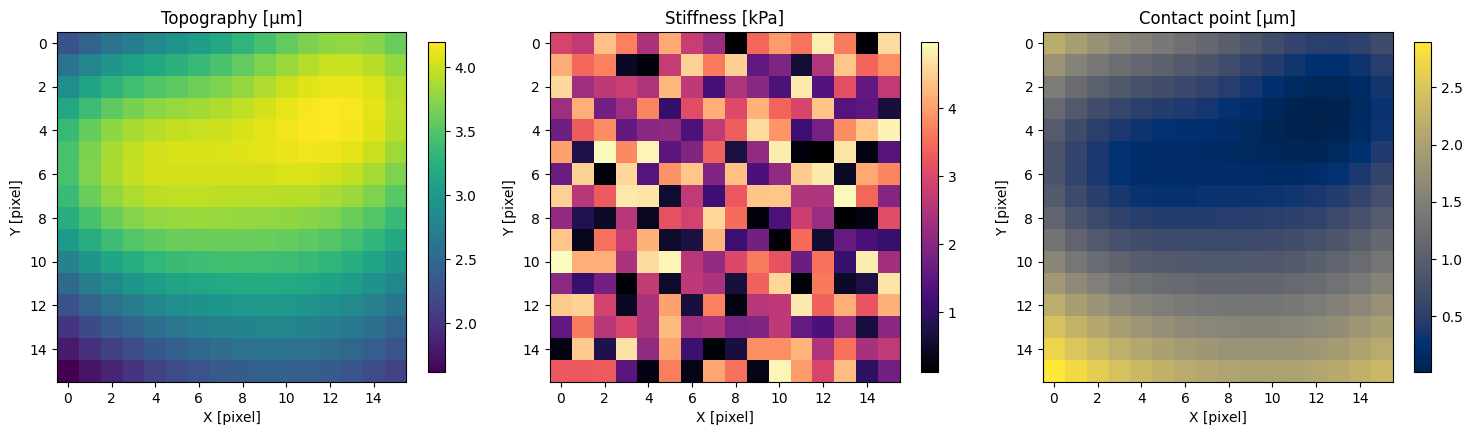

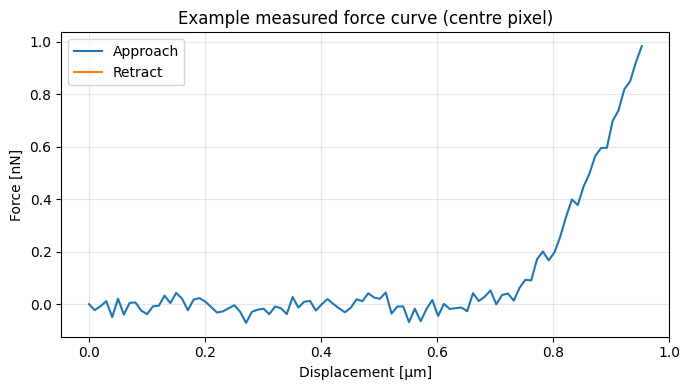

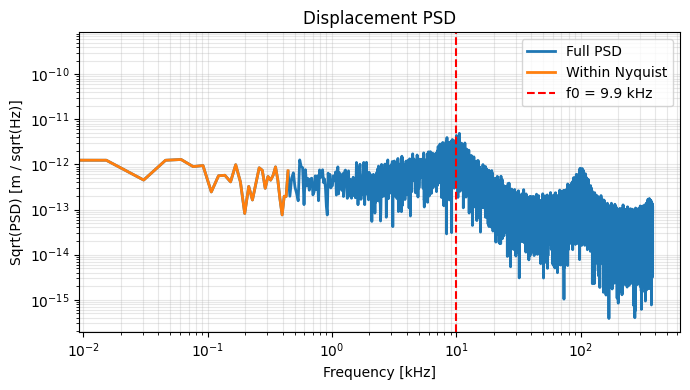

In [10]:
# We use the simulator to generate data and visualise it with the functions
# defined above.

rng = np.random.default_rng(SEED)

cantilever = AFMCantilever(k=0.178, f0=10e3, Q=100.0, T=300.0)
contact_model = HertzContact(R=1e-6, nu=0.5, alpha=18.0)
sample_generator = SampleGenerator(
    substrate_stiffness_range_pa=dataset_config.substrate_stiffness_range_pa,
    feature_stiffness_range_pa=dataset_config.feature_stiffness_range_pa,
    height_range_m=dataset_config.height_range_m,
    contact_point_range_m=dataset_config.contact_point_range_m,
)
simulator = AFMSimulator(
    cantilever=cantilever,
    contact_model=contact_model,
    sample_generator=sample_generator,
    config=simulation_config,
)

print(f"Approach points = {simulator.n_points_approach}")
print(f"Setpoint force range = {min(simulation_config.setpoint_force_n_range) * 1e9:.2f} - {max(simulation_config.setpoint_force_n_range) * 1e9:.2f} nN")

example_topography_m, example_stiffness_pa, example_contact_point_m = (
    sample_generator.create_topography(
        size=(simulation_config.ny, simulation_config.nx),
        pixel_size_m=simulation_config.pixel_size_m,
        topography_type="gaussian_features",
        rng=rng,
    )
)

example_output = simulator.simulate_force_map(
    stiffness_map_pa=example_stiffness_pa,
    contact_point_map_m=example_contact_point_m,
    include_thermal_noise=simulation_config.include_thermal_noise,
    rng=rng,
)

plot_maps(example_topography_m, example_stiffness_pa, example_contact_point_m)

center_row = simulation_config.ny // 16
center_col = simulation_config.nx // 2
plot_force_curve(
    example_output["displacement_curves_m"][center_row, center_col],
    example_output["measured_force_curves_n"][center_row, center_col],
    retract_start_index= \
      int(example_output["retract_start_indices"][center_row, center_col]),
    valid_length=int(example_output["curve_lengths"][center_row, center_col]),
    title="Example measured force curve (centre pixel)",
)

reference_points = max(simulator.n_points_approach * 2, 64)
if simulation_config.noise_type == "rms":
    frequency_hz, spectral_density_m2_per_hz = cantilever.get_noise_psd(
        n_points=reference_points,
        sampling_frequency_hz=cantilever.f0*10,
        noise_type="theoretical",
        experimental_path=simulation_config.experimental_noise_path,
    )

else:
    frequency_hz, spectral_density_m2_per_hz = cantilever.get_noise_psd(
        n_points=reference_points,
        sampling_frequency_hz=cantilever.f0*10,
        noise_type=simulation_config.noise_type,
        experimental_path=simulation_config.experimental_noise_path,
    )
plot_psd(
    frequency_hz,
    spectral_density_m2_per_hz,
    cantilever,
    sampling_frequency=simulation_config.sampling_frequency_hz,
)


## 8. Instantiate the simulator and generate one example sample

## 9. Curve Generation and Preprocessing

Generate the curves and interpolate the tip displament and measured force to fix length ...

In [11]:
align_length = 1500

data_x = []
data_y = []

rng = np.random.default_rng(577)
ny = simulator.config.ny
nx = simulator.config.nx

for i in range(dataset_config.n_samples):
    topography_type = rng.choice(dataset_config.topography_types)
    topo_m, stiff_pa, cp_m = sample_generator.create_topography(
        size=(ny, nx),
        pixel_size_m=simulator.config.pixel_size_m,
        topography_type=topography_type,
        rng=rng,
    )
    out = simulator.simulate_force_map(
        stiffness_map_pa=stiff_pa,
        contact_point_map_m=cp_m,
        include_thermal_noise=simulator.config.include_thermal_noise,
        noise_type=simulator.config.noise_type,
        experimental_path=simulator.config.experimental_noise_path,
        rng=rng,
    )

    for r in range(ny):
        for c in range(nx):
            vl = int(out["curve_lengths"][r, c])
            disp = out["displacement_curves_m"][r, c]
            disp = np.asarray(disp, dtype=np.float64)
            meas = out["measured_force_curves_n"][r, c]
            meas = np.asarray(meas, dtype=np.float64)
            stif = float(stiff_pa[r, c])
            cp = float(cp_m[r, c])

            x_old = np.linspace(0, 1, vl)
            x_new = np.linspace(0, 1, align_length)
    
            disp = np.interp(x_new, x_old, disp)
            meas = np.interp(x_new, x_old, meas)

            disp = disp.max() - disp

            data_x.append(np.hstack([disp*1e6,meas*1e9]))
            data_y.append([cp, stif])

data_x = np.array(data_x)
data_y = np.array(data_y)

... and create the dataloader for tranining.

In [12]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

y_scaler = MinMaxScaler()
data_y_n = y_scaler.fit_transform(data_y)

x_train, x_test, y_train, y_test = train_test_split(
    data_x, data_y_n,
    test_size=0.3,
    random_state=577
)

train_dataset = TensorDataset(
    torch.tensor(x_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32)
)

val_dataset = TensorDataset(
    torch.tensor(x_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.float32)
)

train_loader = DataLoader(train_dataset, batch_size=4096)
val_loader = DataLoader(val_dataset, batch_size=4096)

## 10. MLP Training

Instantiate a dense layers neural network ...

In [13]:
import deeplay as dl

mlp_model = dl.MultiLayerPerceptron(
    in_features=2*align_length, hidden_features=[1024, 256], out_features=2,
).create()

... and print the network structure ...

In [14]:
print(mlp_model)

MultiLayerPerceptron(
  (blocks): LayerList(
    (0): LinearBlock(
      (layer): Linear(in_features=3000, out_features=1024, bias=True)
      (activation): ReLU()
    )
    (1): LinearBlock(
      (layer): Linear(in_features=1024, out_features=256, bias=True)
      (activation): ReLU()
    )
    (2): LinearBlock(
      (layer): Linear(in_features=256, out_features=2, bias=True)
      (activation): Identity()
    )
  )
)


... compile it ...

In [15]:
from torch.nn import MSELoss as MSE
from torchmetrics import MeanAbsoluteError as MAE

regressor = dl.Regressor(
    mlp_model, loss=MSE(), optimizer=dl.Adam(lr=1e-4), metrics=[MAE()],
).create()

... and print the summary of the compiled model.

In [16]:
print(regressor)

Regressor(
  (loss): MSELoss()
  (optimizer): Adam[Adam](lr=0.0001)
  (train_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=train
  )
  (val_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=val
  )
  (test_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=test
  )
  (model): MultiLayerPerceptron(
    (blocks): LayerList(
      (0): LinearBlock(
        (layer): Linear(in_features=3000, out_features=1024, bias=True)
        (activation): ReLU()
      )
      (1): LinearBlock(
        (layer): Linear(in_features=1024, out_features=256, bias=True)
        (activation): ReLU()
      )
      (2): LinearBlock(
        (layer): Linear(in_features=256, out_features=2, bias=True)
        (activation): Identity()
      )
    )
  )
)


Instance a trainer with a callback to monitor the validation loss and save the best model ...

In [17]:
from lightning.pytorch.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger

# Save the top-1 model according to the validation loss
checkpoint_callback = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=1,
)

# Set the logger
csv_logger = CSVLogger("logs", name="regressor")

# Instantiate the trainer
trainer = dl.Trainer(
    max_epochs=10000,
    accelerator="auto",
    callbacks=[checkpoint_callback],
    logger=csv_logger,
    log_every_n_steps=5,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


... and train the model.

In [18]:
trainer.fit(regressor, train_loader, val_loader)

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MSELoss              │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │     0 │
│ 4 │ model         │ MultiLayerPerceptron │  3.3 M │ train │     0 │
│ 5 │ optimizer     │ Adam                 │      0 │ train │     0 │
└───┴───────────────┴──────────────────────┴────────┴───────┴───────┘

Trainable params: 3.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.3 M                                                                                                
Total estimated model params size (MB): 13                                                                         
Modules in train mode: 19                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

/home/demirpehlivan/envnaz/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/home/demirpehlivan/envnaz/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |                                               | 0/? [00:00<?, ?it/s]

...

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/home/demirpehlivan/envnaz/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


Extract the training metrics ...

In [ ]:
import pandas as pd

version = 0
logs = pd.read_csv(os.path.join("logs", "regressor", f"version_{version}",
                             "metrics.csv"))

# Group by epoch and extract train loss and MAE.
train_epoch = logs[logs.train_loss_epoch.notnull()].epoch
train_loss = logs[logs.train_loss_epoch.notnull()].train_loss_epoch
train_mae = (logs[logs.trainMeanAbsoluteError_epoch.notnull()]
             .trainMeanAbsoluteError_epoch)

# Group by epoch and extract val loss and MAE.
val_epoch = logs[logs.val_loss_epoch.notnull()].epoch
val_loss = logs[logs.val_loss_epoch.notnull()].val_loss_epoch
val_mae = (logs[logs.valMeanAbsoluteError_epoch.notnull()]
           .valMeanAbsoluteError_epoch)

... and plot the training history.

In [ ]:
plt.plot(train_epoch, train_loss, label="train", c="gray", linestyle="--")
plt.plot(val_epoch, val_loss, label="val", c="orange")
plt.title("Loss (MSE)", fontsize=24)
plt.xlabel("Epoch", fontsize=16)
plt.ylabel("Loss (MSE)", fontsize=16)
plt.tick_params(axis="both", which="major", labelsize=8)
plt.legend(fontsize=16)
plt.show()

plt.plot(train_epoch, train_mae, label="train", c="gray", linestyle="--")
plt.plot(val_epoch, val_mae, label="val", c="orange")
plt.title("MAE", fontsize=24)
plt.xlabel("Epoch", fontsize=16)
plt.ylabel("MAE", fontsize=16)
plt.tick_params(axis="both", which="major", labelsize=8)
plt.legend(fontsize=16)
plt.show()

## 11. Evaluate on the Generated Map

Load the best model from the callback function.

In [128]:
print(f"The best model is saved at {checkpoint_callback.best_model_path}")

checkpoint_callback.best_model_path = 'logs/regressor/version_2/checkpoints/epoch=990-step=87208.ckpt'
best_regressor = dl.Regressor.load_from_checkpoint(
    checkpoint_callback.best_model_path
)

# Uncomment if you want to load a pretrained model

# pretraiend_model_path = Path.cwd() / "models" / "epoch=1949-step=7800.ckpt"

# print(f"Loading the model at {pretraiend_model_path}")

# best_regressor = dl.Regressor.load_from_checkpoint(
#     pretraiend_model_path
# )

The best model is saved at logs/regressor/version_2/checkpoints/epoch=990-step=87208.ckpt


Plot the map-level example again ...

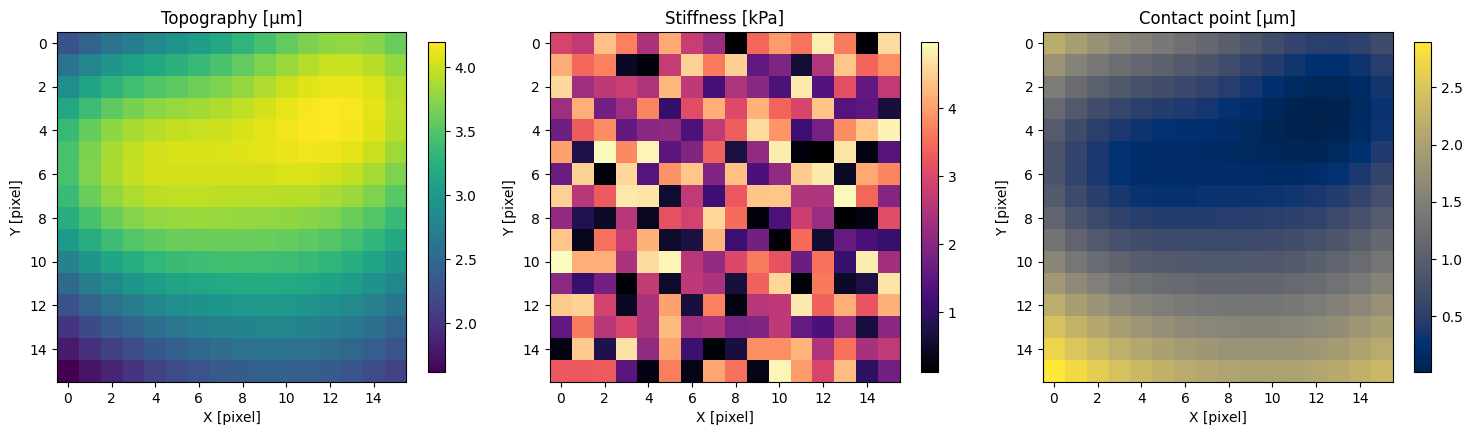

In [129]:
plot_maps(example_topography_m, example_stiffness_pa, example_contact_point_m)

... and process them for model inference.

In [130]:
data_example_x = []
data_example_y = []

for r in range(ny):
    for c in range(nx):
        vl = int(example_output["curve_lengths"][r, c])
        disp = example_output["displacement_curves_m"][r, c]
        disp = np.asarray(disp, dtype=np.float64)
        meas = example_output["measured_force_curves_n"][r, c]
        meas = np.asarray(meas, dtype=np.float64)
        stif = float(example_stiffness_pa[r, c])
        cp = float(example_contact_point_m[r, c])

        x_old = np.linspace(0, 1, vl)
        x_new = np.linspace(0, 1, align_length)

        disp = np.interp(x_new, x_old, disp)
        meas = np.interp(x_new, x_old, meas)

        disp = disp.max() - disp

        data_example_x.append(np.hstack([disp*1e6,meas*1e9]))
        data_example_y.append([cp, stif])

data_example_x = np.array(data_example_x)
data_example_y = np.array(data_example_y)

data_example_y_n = y_scaler.transform(data_example_y)

test_dataset = TensorDataset(
    torch.tensor(data_example_x, dtype=torch.float32),
    torch.tensor(data_example_y_n, dtype=torch.float32)
)

test_loader = DataLoader(test_dataset, batch_size=nx*ny, shuffle=False)

Calculate the metrics in generated map ...

In [131]:
_ = trainer.test(best_regressor, test_loader)

/home/demirpehlivan/envnaz/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |                                                | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃         Test metric         ┃        DataLoader 0         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ testMeanAbsoluteError_epoch │    0.013859927654266357     │
│       test_loss_epoch       │    0.000620729464571923     │
└─────────────────────────────┴─────────────────────────────┘

... and predict the contact points and stiffness ...

In [132]:
from sklearn.metrics import mean_squared_error

best_regressor.eval()

with torch.no_grad():
    for batch in test_loader:
        x, y = batch
        y_hat = best_regressor(x)

y = y.numpy()
y_hat = y_hat.numpy()

y_original = y_scaler.inverse_transform(y)
y_hat_original = y_scaler.inverse_transform(y_hat)


y_original[:,0] *= 1e9
y_hat_original[:,0] *= 1e9

y_original[:,1] /= 1e3
y_hat_original[:,1] /= 1e3

print(f"Test Contact-Point RMSE: {mean_squared_error(y_original[:,0],y_hat_original[:,0])} nm")
print(f"Test stiffness RMSE: {mean_squared_error(y_original[:,1], y_hat_original[:,1])} kPa")

Test Contact-Point RMSE: 2099.083251953125 nm
Test stiffness RMSE: 0.02377285435795784 kPa


... and make the comparision figure between true and prediction.

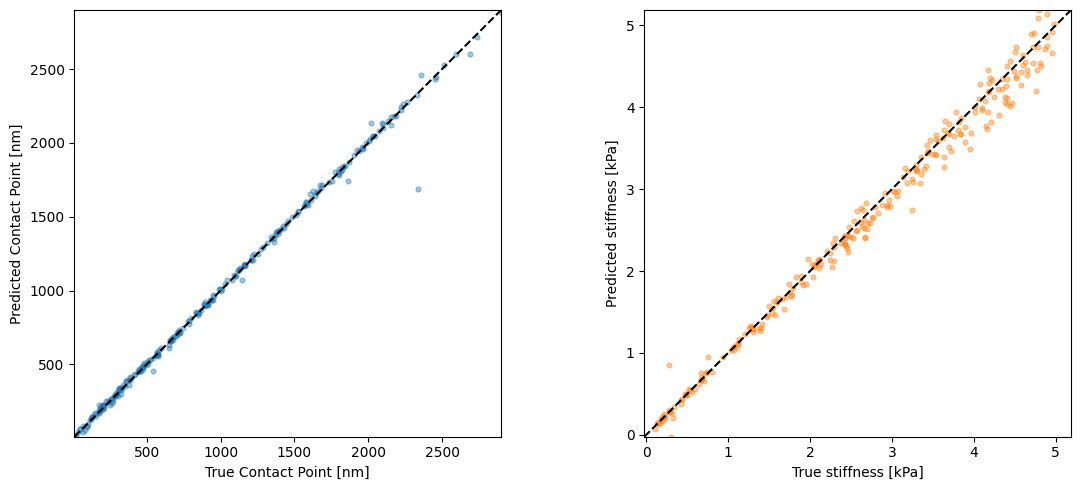

In [133]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_original[:,0], 
                y_hat_original[:,0], 
                alpha=0.4, 
                s=12)
lim = [min(y_original[:,0].min(), y_hat_original[:,0].min()), 
       max(y_original[:,0].max(), y_hat_original[:,0].max())]
axes[0].plot(lim, lim, "k--", lw=1.5, label="Perfect")
axes[0].set_xlim(lim)
axes[0].set_ylim(lim)
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlabel("True Contact Point [nm]")
axes[0].set_ylabel("Predicted Contact Point [nm]")

axes[1].scatter(y_original[:,1], 
                y_hat_original[:,1], 
                alpha=0.4, 
                s=12, 
                color="tab:orange",)
lim = [min(y_original[:,1].min(), y_hat_original[:,1].min()), 
       max(y_original[:,1].max(), y_hat_original[:,1].max())]
axes[1].plot(lim, lim, "k--", lw=1.5, label="Perfect")
axes[1].set_xlim(lim)
axes[1].set_ylim(lim)
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_xlabel("True stiffness [kPa]")
axes[1].set_ylabel("Predicted stiffness [kPa]")

plt.tight_layout()
plt.show()

Play with the weight.

In [134]:
# Placeholder for map clickable weight

## 12. Evaluate on the Real Data

Download and load the 3T3 dataset ...

In [135]:
from pathlib import Path

if not os.path.exists("3t3_cell_dataset"):
    os.system("git clone https://github.com/DeepTrackAI/3t3_cell_dataset")

# Load the approach curves
approach_path = Path.cwd() / "3t3_cell_dataset" / "approach"
approach_files = sorted(approach_path.glob("*.npy"), key=lambda f: int(f.stem))
approach_curves = [np.load(f) for f in approach_files]

# Load the retraction curves
retract_path = Path.cwd() / "3t3_cell_dataset" / "retraction"
retract_files = sorted(retract_path.glob("*.npy"), key=lambda f: int(f.stem))
retract_curves = [np.load(f) for f in retract_files]

# Load the labels
label_file = Path.cwd() / "3t3_cell_dataset" / "label.npy"
labels = np.load(label_file)

# Load the contact points
contactpoint_file = Path.cwd() / "3t3_cell_dataset" / "contact_point.npy"
contactpoints = np.load(contactpoint_file)

# Load the contact points
young_modulus_file = Path.cwd() / "3t3_cell_dataset" / "young_modulus.npy"
young_modulus = np.load(young_modulus_file)

... and process them for model inference.

In [136]:
data_real_x = []
data_real_y = []

for indx in range(len(approach_curves)):
    curve = approach_curves[indx]
    vl = curve.shape[0]
    disp = curve[:,0]
    disp = np.asarray(disp, dtype=np.float64)
    meas = curve[:,1]
    meas = np.asarray(meas, dtype=np.float64)
    stif = float(young_modulus[indx])
    cp = float(contactpoints[indx])

    x_old = np.linspace(0, 1, vl)
    x_new = np.linspace(0, 1, align_length)

    disp = np.interp(x_new, x_old, disp)
    meas = np.interp(x_new, x_old, meas)

    cp = disp.max() - cp
    disp = disp.max() - disp
    

    data_real_x.append(np.hstack([disp[::-1],meas]))
    data_real_y.append([cp/1e6, stif])

data_real_x = np.array(data_real_x)
data_real_y = np.array(data_real_y)

data_real_y_n = y_scaler.transform(data_real_y)

real_dataset = TensorDataset(
    torch.tensor(data_real_x, dtype=torch.float32),
    torch.tensor(data_real_y_n, dtype=torch.float32)
)

real_loader = DataLoader(real_dataset, batch_size=data_real_x.shape[0], shuffle=False)

Predict the contact points and stiffness for experimental data ...

In [137]:
with torch.no_grad():
    for batch in real_loader:
        x, y = batch
        y_hat = best_regressor(x)

y = y.numpy()
y_hat = y_hat.numpy()

y_original = y_scaler.inverse_transform(y)
y_hat_original = y_scaler.inverse_transform(y_hat)


y_original[:,0] *= 1e9
y_hat_original[:,0] *= 1e9

y_original[:,1] /= 1e3
y_hat_original[:,1] /= 1e3

... and make the comparision figure between true and prediction in good quality data.

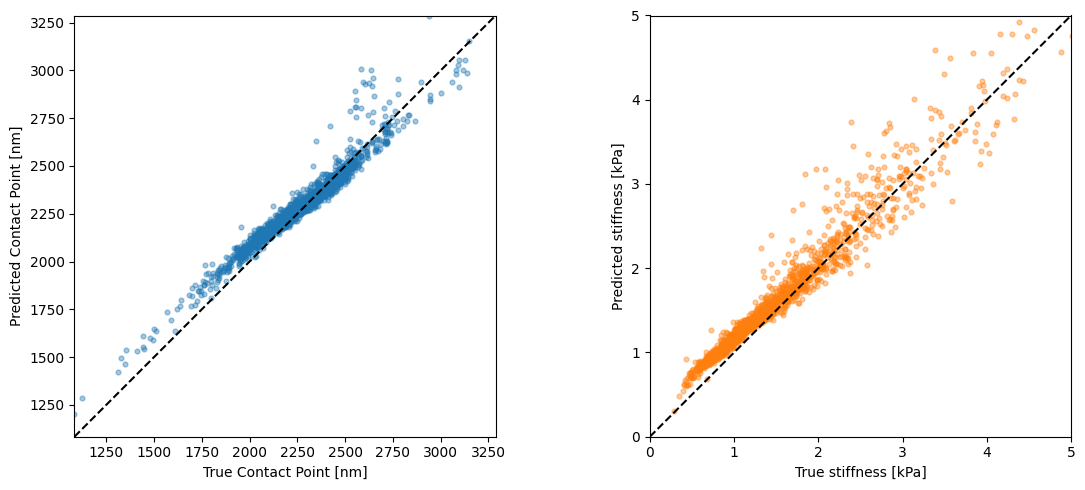

In [138]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y_original_select = y_original[labels==1]
y_hat_original_select = y_hat_original[labels==1]

axes[0].scatter(y_original_select[:,0], 
                y_hat_original_select[:,0], 
                alpha=0.4, 
                s=12)
lim = [min(y_original_select[:,0].min(), y_hat_original_select[:,0].min()), 
       max(y_original_select[:,0].max(), y_hat_original_select[:,0].max())]
axes[0].plot(lim, lim, "k--", lw=1.5, label="Perfect")
axes[0].set_xlim(lim)
axes[0].set_ylim(lim)
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlabel("True Contact Point [nm]")
axes[0].set_ylabel("Predicted Contact Point [nm]")

axes[1].scatter(y_original_select[:,1], 
                y_hat_original_select[:,1], 
                alpha=0.4, 
                s=12, 
                color="tab:orange",)
lim = [0, 5]
axes[1].plot(lim, lim, "k--", lw=1.5, label="Perfect")
axes[1].set_xlim(lim)
axes[1].set_ylim(lim)
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_xlabel("True stiffness [kPa]")
axes[1].set_ylabel("Predicted stiffness [kPa]")

plt.tight_layout()
plt.show()

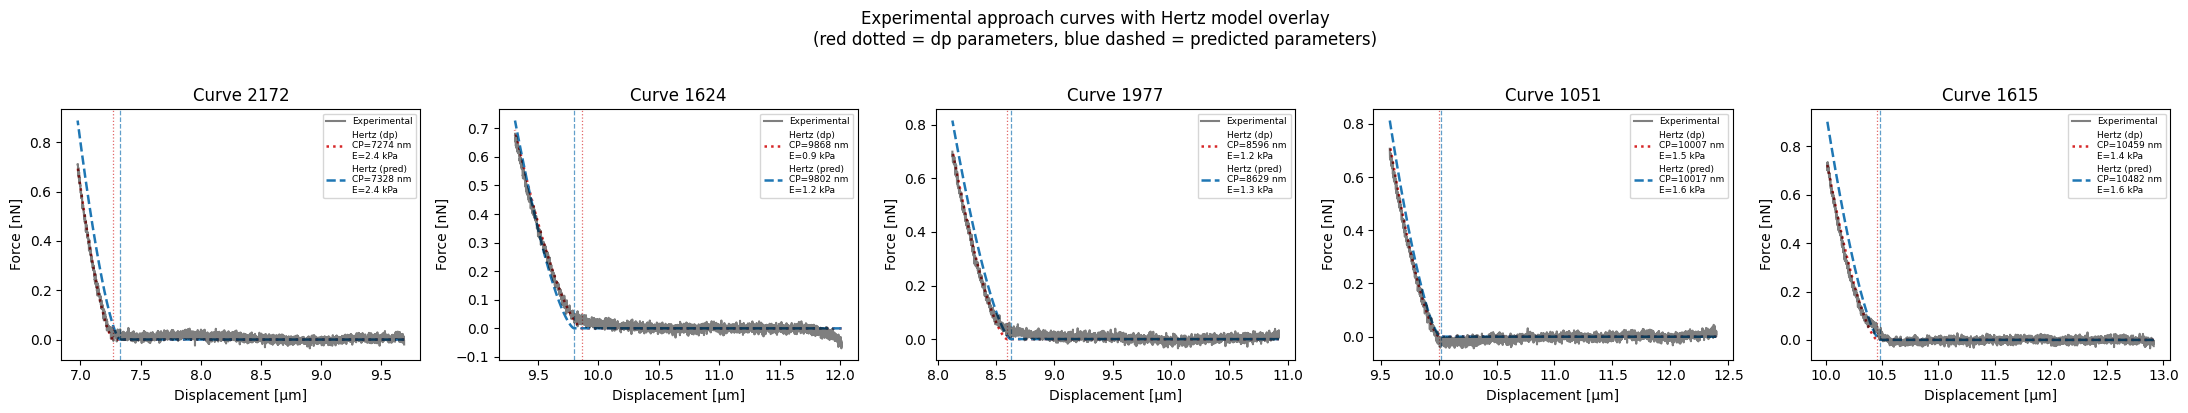

In [139]:
rng_plot = np.random.default_rng(42)
good_idx = np.where(labels == 1)[0]
sel_idx = rng_plot.choice(good_idx, size=5, replace=False)

def fitting_plotting(approach_curves, idx):
    # Raw approach curve: col 0 = displacement (µm, decreasing), col 1 = force (nN)
    curve = approach_curves[idx]
    disp_um = curve[:, 0]
    force_nN = curve[:, 1]
    disp_max_um = float(disp_um.max())

    # ── Dp parameters ──────────────────────────────────────────────────────
    cp_dp_um = float(contactpoints[idx])       # µm, raw coordinate
    e_dp_pa  = float(young_modulus[idx])        # Pa

    # ── Predicted parameters ─────────────────────────────────────────────────
    # Model predicts cp in the inverted coordinate (nm): cp_inv = disp_max - cp_raw
    # Reverse: cp_raw_um = disp_max_um - cp_pred_nm / 1000
    cp_pred_um = disp_max_um - float(y_hat_original[idx, 0]) / 1000.0  # µm
    e_pred_pa  = float(y_hat_original[idx, 1]) * 1e3                   # Pa

    # ── Indentation (displacement decreases during approach) ──────────────────
    # Indentation = max(0, cp - disp)
    indent_dp_m = np.maximum(cp_dp_um - disp_um, 0.0) * 1e-6
    indent_pred_m = np.maximum(cp_pred_um - disp_um, 0.0) * 1e-6

    # ── Hertz force curves ────────────────────────────────────────────────────
    f_hertz_dp_nN = contact_model.force(
        simulation_config.tip_shape, indent_dp_m, e_dp_pa
    ) * 1e9
    f_hertz_pred_nN = contact_model.force(
        simulation_config.tip_shape, indent_pred_m, e_pred_pa
    ) * 1e9
    return disp_um, force_nN, cp_dp_um, cp_pred_um, e_dp_pa, e_pred_pa, f_hertz_dp_nN, f_hertz_pred_nN

fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=False)

for ax, idx in zip(axes, sel_idx):

    disp_um, force_nN, cp_dp_um, cp_pred_um, e_dp_pa, e_pred_pa, f_hertz_dp_nN, f_hertz_pred_nN = fitting_plotting(approach_curves, idx)
    
    # ── Plot ──────────────────────────────────────────────────────────────────
    ax.plot(disp_um, force_nN, color="black", lw=1.5, label="Experimental", zorder=3, alpha=0.5)
    ax.plot(disp_um, f_hertz_dp_nN, color="tab:red",  lw=1.8, ls=":",
            label=f"Hertz (dp)\nCP={cp_dp_um*1000:.0f} nm\nE={e_dp_pa/1e3:.1f} kPa")
    ax.plot(disp_um, f_hertz_pred_nN, color="tab:blue", lw=1.8, ls="--",
            label=f"Hertz (pred)\nCP={cp_pred_um*1000:.0f} nm\nE={e_pred_pa/1e3:.1f} kPa")
    ax.axvline(cp_dp_um, color="tab:red",  lw=0.9, ls=":", alpha=0.7)
    ax.axvline(cp_pred_um, color="tab:blue", lw=0.9, ls="--", alpha=0.7)
    ax.set_xlabel("Displacement [µm]")
    ax.set_ylabel("Force [nN]")
    ax.set_title(f"Curve {idx}")
    ax.legend(fontsize=6.5)

plt.suptitle(
    "Experimental approach curves with Hertz model overlay\n"
    "(red dotted = dp parameters, blue dashed = predicted parameters)",
    y=1.02,
)
plt.tight_layout()
plt.show()

### RMSE between experimental curves and Hertz fits

For each curve we compute the RMSE between the experimental force signal and the Hertz model evaluated at both the **dp estimated** and the **predicted** parameters. Comparing the two distributions reveals whether the model's parameter estimates produce fits that are as faithful to the raw data as the dp fit.

In [140]:
n_curves = len(approach_curves)
rmse_dp_arr = np.zeros(n_curves)
rmse_pred_arr = np.zeros(n_curves)

for idx in range(n_curves):
    disp_um, force_nN, cp_dp_um, cp_pred_um, e_dp_pa, e_pred_pa, f_hertz_dp_nN, f_hertz_pred_nN = fitting_plotting(approach_curves, idx)
    if len(force_nN) == len(f_hertz_dp_nN):
        rmse_dp_arr[idx] = np.sqrt(np.mean((force_nN - f_hertz_dp_nN) ** 2))
        rmse_pred_arr[idx] = np.sqrt(np.mean((force_nN - f_hertz_pred_nN) ** 2))

good_idx       = np.where(labels == 1)[0]
rmse_dp_good = rmse_dp_arr[good_idx]
rmse_pred_good = rmse_pred_arr[good_idx]

print(f"Good-quality curves : {len(good_idx)}")
print(f"RMSE (dp params)  – mean: {rmse_dp_good.mean():.4f} nN  "
      f"median: {np.median(rmse_dp_good):.4f} nN")
print(f"RMSE (pred params)  – mean: {rmse_pred_good.mean():.4f} nN  "
      f"median: {np.median(rmse_pred_good):.4f} nN")
print(f"Curves where pred fit is better than truth: "
      f"{(rmse_pred_good < rmse_dp_good).sum()} / {len(good_idx)}")

Good-quality curves : 1639
RMSE (dp params)  – mean: 0.0137 nN  median: 0.0134 nN
RMSE (pred params)  – mean: 0.0310 nN  median: 0.0271 nN
Curves where pred fit is better than truth: 12 / 1639


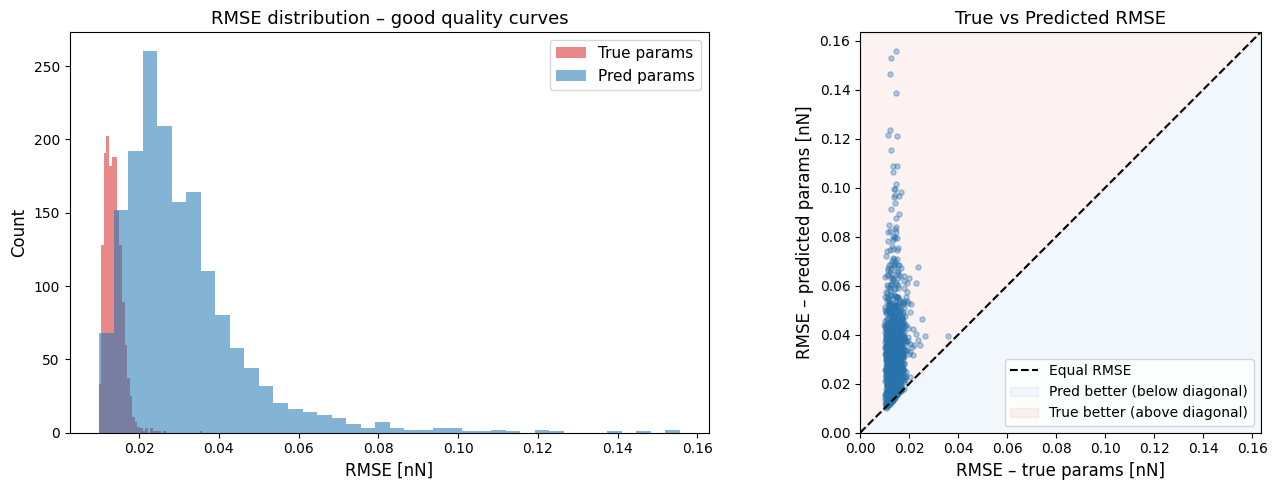

In [141]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Overlapping histograms ─────────────────────────────────────────────────
axes[0].hist(rmse_dp_good, bins=40, alpha=0.55, color="tab:red",  label="True params")
axes[0].hist(rmse_pred_good, bins=40, alpha=0.55, color="tab:blue", label="Pred params")
axes[0].set_xlabel("RMSE [nN]", fontsize=12)
axes[0].set_ylabel("Count",     fontsize=12)
axes[0].set_title("RMSE distribution – good quality curves", fontsize=13)
axes[0].legend(fontsize=11)

# ── Scatter: RMSE_true vs RMSE_pred, diagonal = equal performance ──────────
max_lim = max(rmse_dp_good.max(), rmse_pred_good.max()) * 1.05
axes[1].scatter(rmse_dp_good, rmse_pred_good, alpha=0.35, s=14)
axes[1].plot([0, max_lim], [0, max_lim], "k--", lw=1.5, label="Equal RMSE")
axes[1].fill_between([0, max_lim], [0, 0], [0, max_lim],
                     alpha=0.06, color="tab:blue",
                     label="Pred better (below diagonal)")
axes[1].fill_between([0, max_lim], [0, max_lim], [max_lim, max_lim],
                     alpha=0.06, color="tab:red",
                     label="True better (above diagonal)")
axes[1].set_xlim(0, max_lim)
axes[1].set_ylim(0, max_lim)
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_xlabel("RMSE – true params [nN]",      fontsize=12)
axes[1].set_ylabel("RMSE – predicted params [nN]", fontsize=12)
axes[1].set_title("True vs Predicted RMSE",        fontsize=13)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

#### Curves with the largest RMSE discrepancy

Sort good-quality curves by `RMSE_pred − RMSE_true`.

* **Top row** — predicted fit is better than the truth fit (most negative difference): the model may have found a better parameter set, or the ground-truth annotation is imprecise.  
* **Bottom row** — truth fit is far better than the predicted fit (most positive difference): the model struggled on these curves.

Pred fit BETTER  – curve indices: 1696  Δ RMSE: -0.0004
DP fit BETTER  – curve indices: [1748]  Δ RMSE: [0.1411]


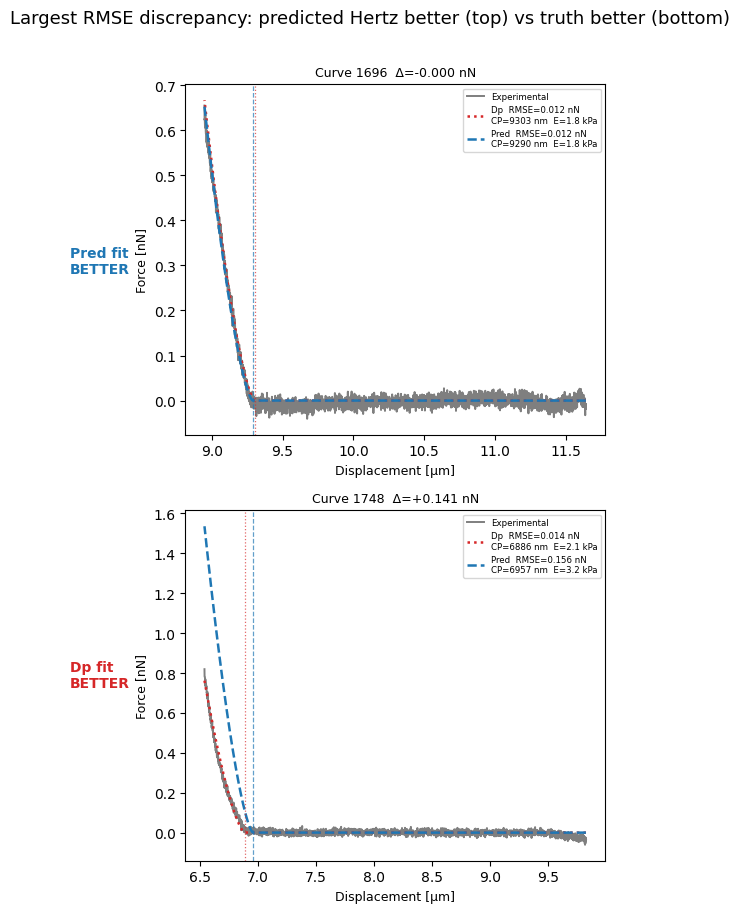

In [144]:
diff_good = rmse_pred_good - rmse_dp_good   # negative → pred better

n_show = 1
pred_better_local = np.argsort(diff_good)[n_show]   # most negative
dp_better_local = np.argsort(diff_good)[-n_show:]   # most positive

pred_better_idx = good_idx[pred_better_local]
dp_better_idx = good_idx[dp_better_local]

print("Pred fit BETTER  – curve indices:", pred_better_idx,
      " Δ RMSE:", diff_good[pred_better_local].round(4))
print("DP fit BETTER  – curve indices:", dp_better_idx,
      " Δ RMSE:", diff_good[dp_better_local].round(4))


def _plot_discrepancy_row(indices, ax_row):
    for ax, idx in zip(ax_row, indices):
        
        disp_um, force_nN, cp_dp_um, cp_pred_um, e_dp_pa, e_pred_pa, f_dp, f_pred = fitting_plotting(approach_curves, idx)

        r_dp = np.sqrt(np.mean((force_nN - f_dp) ** 2))
        r_pred = np.sqrt(np.mean((force_nN - f_pred) ** 2))

        ax.plot(disp_um, force_nN, "k",        lw=1.4, alpha=0.5, label="Experimental")
        ax.plot(disp_um, f_dp,   "tab:red",  lw=1.8, ls=":",
                label=f"Dp  RMSE={r_dp:.3f} nN\n"
                      f"CP={cp_dp_um*1000:.0f} nm  E={e_dp_pa/1e3:.1f} kPa")
        ax.plot(disp_um, f_pred,   "tab:blue", lw=1.8, ls="--",
                label=f"Pred  RMSE={r_pred:.3f} nN\n"
                      f"CP={cp_pred_um*1000:.0f} nm  E={e_pred_pa/1e3:.1f} kPa")
        ax.axvline(cp_dp_um, color="tab:red",  lw=0.9, ls=":", alpha=0.7)
        ax.axvline(cp_pred_um, color="tab:blue", lw=0.9, ls="--", alpha=0.7)
        ax.set_xlabel("Displacement [µm]", fontsize=9)
        ax.set_title(f"Curve {idx}  Δ={rmse_pred_arr[idx]-rmse_dp_arr[idx]:+.3f} nN",
                     fontsize=9)
        ax.legend(fontsize=6.2)


fig, axes = plt.subplots(2, n_show, figsize=(5 * n_show, 9), sharey=False)



_plot_discrepancy_row([pred_better_idx], [axes[0]])

_plot_discrepancy_row(dp_better_idx, [axes[1]])

for ax in [axes[0]]:
    ax.set_ylabel("Force [nN]", fontsize=9)
for ax in [axes[1]]:
    ax.set_ylabel("Force [nN]", fontsize=9)

axes[0].set_title(
    f"Curve {pred_better_idx}  Δ={rmse_pred_arr[pred_better_idx]-rmse_dp_arr[pred_better_idx]:+.3f} nN",
    fontsize=9)

fig.text(-0.1, 0.73, "Pred fit\nBETTER", ha="left", va="center",
         fontsize=10, fontweight="bold", color="tab:blue")
fig.text(-0.1, 0.27, "Dp fit\nBETTER", ha="left", va="center",
         fontsize=10, fontweight="bold", color="tab:red")

plt.suptitle(
    "Largest RMSE discrepancy: predicted Hertz better (top) vs truth better (bottom)",
    y=1.01, fontsize=13,
)
plt.tight_layout()
plt.show()

[ 224  336  638  759  806  817  842  851  862 1060 1074 1082 1543 1564
 1573 1593 1616]


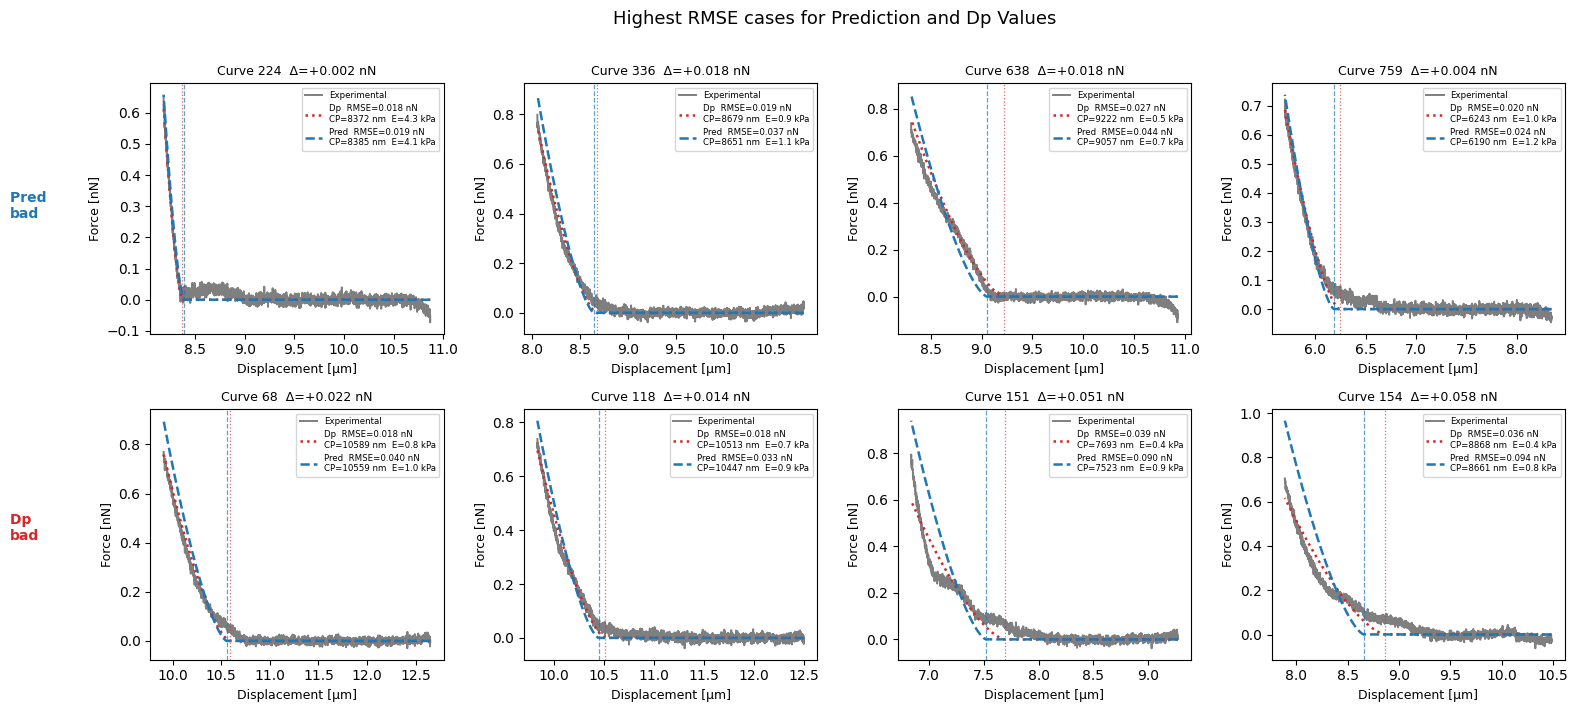

In [147]:
indxs_0 = np.where(rmse_pred_good>np.percentile(rmse_pred_good, 99))[0]
indxs_1 = np.where(rmse_dp_good>np.percentile(rmse_dp_good, 99))[0]

print(indxs_0)
n_curves=4
fig, axes = plt.subplots(2, n_curves, figsize=(15 * n_show, 7), sharey=False)

_plot_discrepancy_row(indxs_0[:n_curves], axes[0])
_plot_discrepancy_row(indxs_1[:n_curves], axes[1])

for ax in axes[0]:
    ax.set_ylabel("Force [nN]", fontsize=9)
for ax in axes[1]:
    ax.set_ylabel("Force [nN]", fontsize=9)

fig.text(-0.05, 0.73, "Pred \nbad", ha="left", va="center",
         fontsize=10, fontweight="bold", color="tab:blue")
fig.text(-0.05, 0.27, "Dp \nbad", ha="left", va="center",
         fontsize=10, fontweight="bold", color="tab:red")

plt.suptitle(
    "Highest RMSE cases for Prediction and Dp Values",
    y=1.01, fontsize=13,
)
plt.tight_layout()
plt.show()

[   0    1    2 ... 1636 1637 1638]


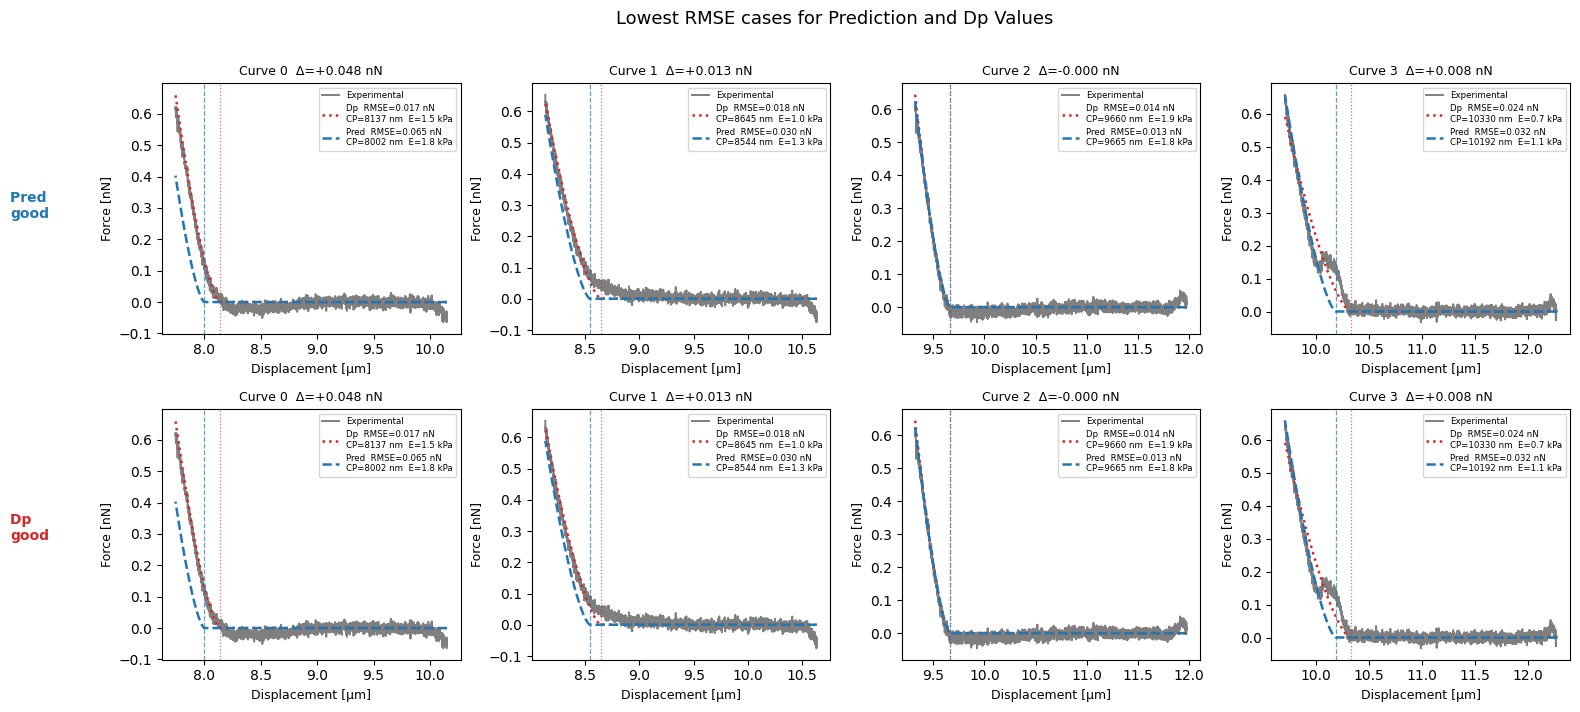

In [148]:
indxs_0 = np.where(rmse_pred_good<np.percentile(rmse_pred_good, 99))[0]
indxs_1 = np.where(rmse_dp_good<np.percentile(rmse_dp_good, 99))[0]

print(indxs_0)
n_curves = 4
fig, axes = plt.subplots(2, n_curves, figsize=(15 * n_show, 7), sharey=False)

_plot_discrepancy_row(indxs_0[:n_curves], axes[0])
_plot_discrepancy_row(indxs_1[:n_curves], axes[1])

for ax in axes[0]:
    ax.set_ylabel("Force [nN]", fontsize=9)
for ax in axes[1]:
    ax.set_ylabel("Force [nN]", fontsize=9)

fig.text(-0.05, 0.73, "Pred \ngood", ha="left", va="center",
         fontsize=10, fontweight="bold", color="tab:blue")
fig.text(-0.05, 0.27, "Dp \ngood", ha="left", va="center",
         fontsize=10, fontweight="bold", color="tab:red")

plt.suptitle(
    "Lowest RMSE cases for Prediction and Dp Values",
    y=1.01, fontsize=13,
)
plt.tight_layout()
plt.show()

Play with the weight.

In [ ]:
# Placeholder for clickable weight that shows the comparision between 
# ML infer parameter-based curve Herz model reconstruction and
# groundtruth-based one

!!! End of My Version

In [ ]:
from pathlib import Path
from IPython.display import display
import matplotlib
import matplotlib.animation

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except Exception:
    output = None

try:
    import anywidget
    import ipywidgets as widgets
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
    print("Plotly FigureWidget is available.")
except Exception as error:
    widgets = None
    go = None
    PLOTLY_AVAILABLE = False
    print("Interactive Plotly viewer is unavailable in this environment.")
    print("Install these packages locally and restart the kernel:")
    print("pip install plotly anywidget ipywidgets")
    print(f"Import error: {error}")


def show_curve_for_pixel(
    sample_index: int,
    row_index: int,
    col_index: int
) -> None:
    """Static fallback: plot the force curve for one pixel.

    Parameters
    ----------
    sample_index : int
        Index of the sample to display.
    row_index : int
        Row index of the pixel to display.
    col_index : int
        Column index of the pixel to display.

    Returns
    -------
    None
        Displays a plot of the force curve for the specified pixel.

    """

    displacement_curves_um = test_collection["displacement_curves_um"]
    displacement_curve_um = \
      displacement_curves_um[sample_index, row_index, col_index]
    curves_nN = test_collection["measured_force_curves_nN"]
    curve_nN = curves_nN[sample_index, row_index, col_index]
    curve_lengths = test_collection["curve_lengths"]
    valid_length = int(curve_lengths[sample_index, row_index, col_index])
    retract_indices = test_collection["retract_start_indices"]
    retract_start = int(retract_indices[sample_index, row_index, col_index])
    stiffness_maps_kpa = test_collection["stiffness_maps_kpa"]
    true_kpa = stiffness_maps_kpa[sample_index, row_index, col_index]
    pred_kpa = predicted_stiffness_maps_kpa[sample_index, row_index, col_index]
    title = (
        f"Sample {sample_index}, pixel ({row_index}, {col_index}) | "
        f"true = {true_kpa:.2f} kPa | pred = {pred_kpa:.2f} kPa"
    )
    if model_config.predict_contact_point and \
      predicted_contact_point_maps_nm is not None:
        contact_point_maps = test_collection["contact_point_maps_nm"]
        cp_true = contact_point_maps[sample_index, row_index, col_index]
        cp_pred = \
        predicted_contact_point_maps_nm[sample_index, row_index, col_index]
        title += f" | cp true = {cp_true:.1f} nm | cp pred = {cp_pred:.1f} nm"

    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.plot(displacement_curve_um[:retract_start], curve_nN[:retract_start], \
            label="Approach", linewidth=2.2)
    ax.plot(
        displacement_curve_um[retract_start:valid_length],
        curve_nN[retract_start:valid_length],
        label="Retract",
        linewidth=2.2,
    )
    ax.set_xlabel("Displacement [um]", fontsize=12)
    ax.set_ylabel("Measured force [nN]", fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=11)
    ax.tick_params(labelsize=11)
    plt.tight_layout()
    plt.show()


def display_clickable_stiffness_map(
    sample_index: int = 0,
    map_width: int = 560,
    map_height: int = 560,
    curve_width: int = 980,
    curve_height: int = 560,
) -> None:
    """Display a clickable predicted stiffness map linked to a force-curve
    panel.

    Parameters
    ----------
    sample_index : int, optional
        Index of the sample to display (default is 0).
    map_width : int, optional
        Width of the stiffness map panel in pixels (default is 560).
    map_height : int, optional
        Height of the stiffness map panel in pixels (default is 560).
    curve_width : int, optional
        Width of the force curve panel in pixels (default is 980).
    curve_height : int, optional
        Height of the force curve panel in pixels (default is 560).

    Returns
    -------
    None
        Displays a clickable stiffness map linked to a force-curve panel.

    """

    if not PLOTLY_AVAILABLE:
        print("Interactive viewer not available. Using static fallback.")
        show_curve_for_pixel(sample_index, 0, 0)
        return

    pred_map = predicted_stiffness_maps_kpa[sample_index]
    true_map = test_collection["stiffness_maps_kpa"][sample_index]
    curves_nN = test_collection["measured_force_curves_nN"][sample_index]
    disp_um = test_collection["displacement_curves_um"][sample_index]
    curve_lengths = test_collection["curve_lengths"][sample_index]
    retract_starts = test_collection["retract_start_indices"][sample_index]
    cp_true_map = (
        test_collection["contact_point_maps_nm"][sample_index]
        if model_config.predict_contact_point else None
    )
    cp_pred_map = (
        predicted_contact_point_maps_nm[sample_index]
        if model_config.predict_contact_point and \
          predicted_contact_point_maps_nm is not None
        else None
    )

    heatmap_fig = go.FigureWidget(data=[go.Heatmap(
        z=pred_map,
        colorscale="magma",
        colorbar={"title": "kPa", "thickness": 18},
        hovertemplate="x=%{x}<br>y=%{y}<br>pred=%{z:.2f} kPa<extra></extra>",
    )])
    heatmap_fig.update_layout(
        title={"text": f"Predicted Stiffness Sample {sample_index}", \
               "y": 0.98, "x": 0.5, "xanchor": "center", \
               "yanchor": "top", "font": {"size": 20}},
        xaxis_title="X",
        yaxis_title="Y",
        width=map_width,
        height=map_height,
        margin=dict(l=55, r=20, t=55, b=55),
        font={"size": 14},
    )
    heatmap_fig.update_yaxes(autorange="reversed", tickfont={"size": 12}, \
                             title_font={"size": 15})
    heatmap_fig.update_xaxes(tickfont={"size": 12}, title_font={"size": 15})

    curve_fig = go.FigureWidget(data=[
        go.Scatter(name="Approach", mode="lines", line={"width": 3}),
        go.Scatter(name="Retract", mode="lines", line={"width": 3}),
    ])
    curve_fig.update_layout(
        title={"text": "Select a pixel", "y": 0.98, "x": 0.5, \
               "xanchor": "center", "yanchor": "top", "font": {"size": 18}},
        xaxis_title="Displacement [um]",
        yaxis_title="Force [nN]",
        width=curve_width,
        height=curve_height,
        margin=dict(l=60, r=25, t=75, b=55),
        legend=dict(yanchor="top", y=0.99, xanchor="right", x=0.99, \
                    font={"size": 13}),
        font={"size": 14},
    )
    curve_fig.update_xaxes(tickfont={"size": 12}, title_font={"size": 15})
    curve_fig.update_yaxes(tickfont={"size": 12}, title_font={"size": 15})

    def handle_click(
        trace: go.Scatter,
        points: go.Points,
        selector: go.Selector
    ) -> None:
        """Update the force curve plot based on the clicked pixel in the
        stiffness map.

        Parameters
        ----------
        trace : go.Scatter
            The scatter trace that was clicked.
        points : go.Points
            The points that were clicked, containing the x and y coordinates.
        selector : go.Selector
            The selector object (not used in this function).

        Returns
        -------
        None
            Updates the force curve plot with the data corresponding to the
              clicked pixel.

        """

        if not points.xs:
            return
        col_index = int(points.xs[0])
        row_index = int(points.ys[0])
        valid_length = int(curve_lengths[row_index, col_index])
        retract_start = int(retract_starts[row_index, col_index])
        x_curve = disp_um[row_index, col_index]
        y_curve = curves_nN[row_index, col_index]
        title = (
            f"Pixel ({row_index}, {col_index}) | "
            f"True {true_map[row_index, col_index]:.1f} kPa | "
            f"Predicted {pred_map[row_index, col_index]:.1f} kPa"
        )
        if cp_true_map is not None and cp_pred_map is not None:
            title += (
                f"Contact point true {cp_true_map[row_index, col_index]:.0f}nm"
                f"predicted {cp_pred_map[row_index, col_index]:.0f} nm"
            )
        with curve_fig.batch_update():
            curve_fig.data[0].x = x_curve[:retract_start]
            curve_fig.data[0].y = y_curve[:retract_start]
            curve_fig.data[1].x = x_curve[retract_start:valid_length]
            curve_fig.data[1].y = y_curve[retract_start:valid_length]
            if valid_length < x_curve.shape[0]:
                curve_fig.data[2].x = x_curve[valid_length - 1:]
                curve_fig.data[2].y = y_curve[valid_length - 1:]
            else:
                curve_fig.data[2].x = []
                curve_fig.data[2].y = []
            curve_fig.layout.title.text = title

    heatmap_fig.data[0].on_click(handle_click)
    display(
        widgets.HBox(
            [heatmap_fig, curve_fig],
            layout=widgets.Layout(width="100%", \
                        justify_content="space-between", align_items="center"),
        )
    )


display_clickable_stiffness_map(
    sample_index=model_config.default_sample_to_display
    )

## 16. Testing on Experimental Data

In [ ]:
# 6. CONTACT-MECHANICS OVERLAY: MODEL VS FILE REFERENCE

# Use current contact-model geometry if available, otherwise fall back to a
# typical AFM value used above.
if "contact_model" in globals() and hasattr(contact_model, "R"):
    tip_radius_m = float(contact_model.R)
else:
    tip_radius_m = 1000e-9


def hertz_force_from_cp_and_e(
    z_m: np.ndarray,
    cp_m: float,
    e_pa: float,
    force_exp_n: np.ndarray,
) -> tuple[np.ndarray, str, float]:
    """Compute Hertz force from (cp, E).

    Computes the predicted force curve based on the Hertz contact model using
    the provided contact point and Young's modulus, and calculates the RMSE
    compared to the experimental force values.

    Parameters
    ----------
    z_m : np.ndarray
        Z values in meters.
    cp_m : float
        Contact point in meters.
    e_pa : float
        Young's modulus in Pascals.
    force_exp_n : np.ndarray
        Experimental force values in newtons, used for RMSE calculation.

    Returns
    -------
    tuple[np.ndarray, float]
        Tuple containing the predicted force values in newtons and the RMSE
        compared to the experimental force values.

    """

    z_m = np.asarray(z_m, dtype=np.float64)
    force_exp_n = np.asarray(force_exp_n, dtype=np.float64)

    delta = np.clip(z_m - cp_m, 0.0, None)
    force = contact_model.force(
        cantilever_shape=SimulationConfig.tip_shape,
        indentation_m=delta,
        stiffness_pa=e_pa)
    rmse = float(np.sqrt(np.mean((force - force_exp_n) ** 2)))

    return force, rmse


current_curve_mode = globals().get(
    "experimental_curve_mode",
    globals().get("checkpoint_curve_mode", "approach"),
)
print(f"Overlay curve mode: {current_curve_mode}")

if "comparison_df" not in globals() or comparison_df.empty:
    print("No comparison table found. Run the previous prediction cell first.")
else:
    n_show = len(comparison_df)
    fig, axes = plt.subplots(
        n_show,
        1,
        figsize=(11, max(4.5, 4.0 * n_show)),
        squeeze=False,
    )

    for i in range(n_show):
        ax = axes[i, 0]

        z_m_full = np.asarray(z_phys_list[i], dtype=np.float64)
        f_exp_n_full = np.asarray(f_phys_list[i], dtype=np.float64)
        z_nm_full = z_m_full * 1e9

        if "phase_list" in globals() and i < len(phase_list):
            phase_curve = np.asarray(phase_list[i], dtype=np.float64)
        else:
            phase_curve = None

        has_phase_labels = (
            phase_curve is not None and phase_curve.shape == z_m_full.shape
        )
        has_retract_segment = bool(
            has_phase_labels and np.any(phase_curve < 0) and
            np.any(phase_curve > 0)
        )

        if has_retract_segment:
            approach_mask = phase_curve < 0
            retract_mask = phase_curve > 0
            ax.plot(
                z_nm_full[approach_mask],
                f_exp_n_full[approach_mask] * 1e9,
                color="black",
                lw=2.0,
                label="Experimental approach",
            )
            ax.plot(
                z_nm_full[retract_mask],
                f_exp_n_full[retract_mask] * 1e9,
                color="dimgray",
                lw=1.6,
                alpha=0.9,
                label="Experimental retract",
            )
            z_m = z_m_full[approach_mask]
            f_exp_n = f_exp_n_full[approach_mask]
        else:
            ax.plot(
                z_nm_full,
                f_exp_n_full * 1e9,
                color="black",
                lw=2.0,
                label="Experimental approach",
            )
            z_m = z_m_full
            f_exp_n = f_exp_n_full

        z_nm = z_m * 1e9

        # Model-predicted parameters
        cp_pred_m = np.nan
        e_pred_pa = np.nan
        if "pred_cp_nm" in comparison_df.columns and \
          pd.notna(comparison_df.loc[i, "pred_cp_nm"]):
            cp_pred_m = float(comparison_df.loc[i, "pred_cp_nm"]) * 1e-9
        if "pred_stiffness_kpa" in comparison_df.columns and \
          pd.notna(comparison_df.loc[i, "pred_stiffness_kpa"]):
            e_pred_pa = float(comparison_df.loc[i, "pred_stiffness_kpa"]) * 1e3

        if np.isfinite(cp_pred_m) and np.isfinite(e_pred_pa) and e_pred_pa > 0:
            f_pred_n, rmse_pred_n = hertz_force_from_cp_and_e(
                z_m=z_m,
                cp_m=cp_pred_m,
                e_pa=e_pred_pa,
                force_exp_n=f_exp_n,
            )
            ax.plot(
                z_nm,
                f_pred_n * 1e9,
                color="blue",
                lw=1.8,
                alpha=0.9,
                label=(
                    f"Hertz (model CP/E) | "
                    f"RMSE={rmse_pred_n*1e9:.2f} nN"
                ),
            )
            ax.axvline(
                cp_pred_m * 1e9,
                color="blue",
                ls="--",
                lw=1.0,
                alpha=0.8)

        # File-reference parameters (CP from file adapted to processed z,
        # E from file)
        cp_ref_m = np.nan
        e_ref_pa = np.nan
        if extracted_data["cp_m"][i] is not None:
            cp_raw_m = float(extracted_data["cp_m"][i])
            z_offset_m = float(preprocess_info_list[i].get("z_offset_m", 0.0))
            z_phys_orig_max_m = \
            float(preprocess_info_list[i].get("z_phys_orig_max_m", 0.0))
            cp_phys_orig = aec.adapt_cp_to_processed_z(cp_raw_m, z_offset_m)
            cp_ref_m = z_phys_orig_max_m - cp_phys_orig
        if extracted_data["E_pa"][i] is not None:
            e_ref_pa = float(extracted_data["E_pa"][i])

        if np.isfinite(cp_ref_m) and np.isfinite(e_ref_pa) and e_ref_pa > 0:
            f_ref_n, rmse_ref_n = hertz_force_from_cp_and_e(
                z_m=z_m,
                cp_m=cp_ref_m,
                e_pa=e_ref_pa,
                force_exp_n=f_exp_n,
            )
            ax.plot(
                z_nm,
                f_ref_n * 1e9,
                color="red",
                lw=1.8,
                alpha=0.9,
                label=(
                    f"Hertz (file CP/E) | "
                    f"RMSE={rmse_ref_n*1e9:.2f} nN"
                ),
            )
            ax.axvline(cp_ref_m * 1e9, color="red", ls=":", lw=1.1, alpha=0.9)

        file_label = (
            comparison_df.loc[i, "filename"]
            if "filename" in comparison_df.columns
            else f"Curve {i}"
        )
        curve_label = "approach+retract" if has_retract_segment \
        else "approach-only"
        ax.set_title(f"Curve{i}:{os.path.basename(str(file_label))}")
        ax.set_xlabel("Processed z (nm)")
        ax.set_ylabel("Force (nN)")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9, loc="best")

    plt.tight_layout()
    os.makedirs("results", exist_ok=True)
    overlay_path = "results/hertz_overlay_model_vs_file.png"
    plt.savefig(overlay_path, dpi=160, bbox_inches="tight")
    print(f"Saved overlay figure to: {overlay_path}")
    plt.show()